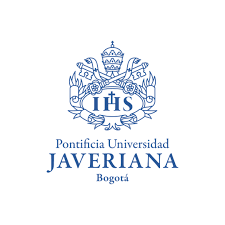

***Pontificia Universidad Javeriana***
# **Big Data Analysis**

### **Lab: Metrics and Machine Learning with PySpark**

Author: Sara Mejia Giraldo

Date: 28/04/2026

## **Methodology**

- Preparation
- Data Wrangling
- EDA
- Preparation for Modeling
- Modeling with Decision Tree, Random Forest, SVM, GBT and Linear Regression
- Performance Evaluation


# **1. Preparation**

## 1.1. Setting Up pip Environment Variables

In [1]:
## Import libraries that will be used
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Libraries for PySpark
from pylab import *

import findspark
findspark.init()

import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc

## 1.2. Initializing the Spark Session
Spark DataFrames were used as an optimized data structure that facilitates exploration, cleaning, transformation, and analysis tasks on large volumes of data efficiently, taking advantage of cluster resources and improving performance compared to traditional methods.

In [2]:
config = SparkConf()
config.set("spark.scheduler.mode", "FAIR")
config.set("spark.scheduler.allocation", "/Almacen/Spark/conf/fairscheduler.xml ")
config.setMaster("spark://10.43.97.171:7077")
config.setAppName("Banca_Mejia_Spark")

sparkMejia = SparkSession.builder.config(conf=config).getOrCreate()
SQLContext(sparkContext=sparkMejia.sparkContext, sparkSession=sparkMejia)
sparkContextoMejia = sparkMejia.sparkContext.getOrCreate()

sparkMejia

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 06:25:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1.3. Loading Data from Hadoop HDFS

Hadoop Distributed File System (HDFS) is Apache Hadoop’s distributed file system. It is designed to store large volumes of data across multiple machines in a cluster simultaneously. It stands out for its high fault tolerance and scalability.
Next, Apache Spark is used to read the CSV file stored in HDFS and load it into a Spark DataFrame.

In [3]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv
### we establish the dataset as a dataframe object 
df00 = sparkMejia.read.format("csv").option("header", "true").option("sep", ";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv")

df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

# **2. Data Wrangling**

## 2.1. Understanding the variables (Columns)

In [4]:
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| age | Feature | Integer | Age | Age of the client. |  | no |
| job | Feature | Categorical | Occupation | type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown') |  | no |
| marital | Feature | Categorical | Marital Status | marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed) |  | no |
| education | Feature | Categorical | Education Level | (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown') |  | no |
| default | Feature | Binary |  | has credit in default? |  | no |
| balance | Feature | Integer |  | average yearly balance | euros | no |
| housing | Feature | Binary |  | has housing loan? |  | no |
| loan | Feature | Binary |  | has personal loan? |  | no |
| contact | Feature | Categorical |  | contact communication type (categorical: 'cellular','telephone') |  | yes |
| day_of_week | Feature | Date |  | last contact day of the week |  | no |
| month | Feature | Date |  | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec') |  | no |
| duration | Feature | Integer |  | last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.|  | no |
| campaign | Feature | Integer |  | number of contacts performed during this campaign and for this client (numeric, includes last contact) |  | no |
| pdays | Feature | Integer |  | number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)|  | yes |
| previous | Feature | Integer |  | number of contacts performed before this campaign and for this client |  | no |
| poutcome | Feature | Integer |  | 	outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')	 |  | yes |
| y | Target | Binary |  | 	has the client subscribed a term deposit? |  | yes |

#### Suggestions:
- One of the goals of this analysis is to build a predictive model, that is why the variable `duration` should be deleted.

## 2.2. Data Types: Consistency and Transformations
To ensure the quality and consistency of the dataset, a review and adjustment of the data types for each variable was carried out.

In [5]:
### show the quantity of data
data_quantity = df00.count()
print("Data quantity:", data_quantity)

[Stage 2:=============================>                             (1 + 1) / 2]

Data quantity: 45211


### 2.2.1. Initial Structure Review

Using Apache Spark’s printSchema() function, the initial schema of the DataFrame was inspected. During this first validation, it was identified that all columns had been loaded as string type.

In [6]:
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



#### Comments:
- All the variables are set as string
- The datatype of the following variables has to be changed from string to integer:
    - `age`, `balance`, `duration`, `campaign`, `pdays`, `previous`
- The last column, named y, is the target variable. The one that we want to predict

### 2.2.2. Definition of expected data types

#### Comments:
- The process for consistently transforming numeric data is shown.
- Keep in mind that visualization using a pandas DataFrame should be used for small objects.

### 2.2.3. Variable transformation
The name of the TARGET variable was changed from y to term_deposit. Then, the casting or data type conversion process was applied, assigning each column the corresponding format. This allowed the database to be prepared for statistical analysis, numerical calculations, and later validations, avoiding errors caused by working with numeric variables as text.

In [7]:
# casting from string to integer
df01 = df00.withColumn("age", df00.age.cast("int"))
df01 = df01.withColumn("balance", df01.balance.cast("int"))
df01 = df01.withColumn("day", df01.day.cast("int"))
df01 = df01.withColumn("duration", df01.duration.cast("int"))
df01 = df01.withColumn("campaign", df01.campaign.cast("int"))
df01 = df01.withColumn("pdays", df01.pdays.cast("int"))
df01 = df01.withColumn("previous", df01.previous.cast("int"))

In [8]:
# name change
df02 = df01.withColumnRenamed('y', 'term_deposit')

### 2.3. Null Data Visualization

In [9]:
df02.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df02.columns]).show()

[Stage 5:=============================>                             (1 + 1) / 2]

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+------------+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|term_deposit|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+------------+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|           0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+------------+



#### Comments:
A visualization of missing values was performed to identify possible null or incomplete data within the dataset. After the analysis, no null values were found in any of the variables, indicating that the dataset is complete and does not require missing data treatment.

### 2.4. Descriptive statistics
A visualization of missing values was performed to identify possible null or incomplete data within the dataset. After the analysis, no null values were found in any of the variables, indicating that the dataset is complete and does not require missing data treatment.

In [10]:
# Reviewed the dataset to see if it is bias
total = df02.count()
df_Y = df02. groupBy("term_deposit").count()
auxPD = df_Y.withColumn("Percentage", df_Y["count"]*100/total)
auxPD.show()

[Stage 11:=============================>                            (1 + 1) / 2]

+------------+-----+------------------+
|term_deposit|count|        Percentage|
+------------+-----+------------------+
|          no|39922| 88.30151954170445|
|         yes| 5289|11.698480458295547|
+------------+-----+------------------+



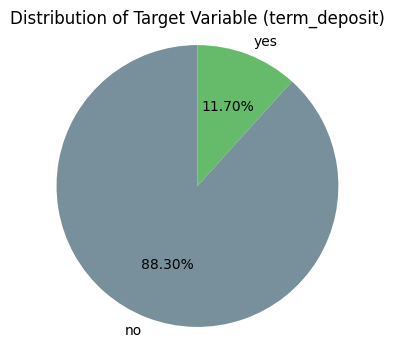

In [11]:
# convert the auxPD dataset from PySpak to Pandas
auxPD_pandas = auxPD.toPandas()

auxPD_pandas["term_deposit"] = auxPD_pandas["term_deposit"].astype(str)
auxPD_pandas = auxPD_pandas.set_index("term_deposit").loc[["yes", "no"]].reset_index()

# Set colors
colores = ["#66BB6A", "#78909C"]  # yes = green, no = gray

plt.figure(figsize=(4, 4))

plt.pie(auxPD_pandas["count"],labels=auxPD_pandas["term_deposit"],autopct="%1.2f%%",startangle=90,colors=colores,counterclock=False)

plt.title("Distribution of Target Variable (term_deposit)")
plt.axis("equal")
plt.show()

#### Bias Observations:
There is a bias in the dataset since almost 90% of the records in the target variable (term_deposit) correspond to "No". 
- The minority class is "Yes", representing 11% with 5,289 records.
- The majority class is "No", representing 88% with 39,922 records.
- The variable is binary, and it is important to avoid introducing additional bias when training predictive models.

#### Recommendations
The distribution of the target variable shows a possible class imbalance. This is important because if one class has a much higher frequency than the other, the predictive model may tend to classify most cases into the dominant class. Therefore, in later stages, evaluating the model only with accuracy will not be sufficient, since this metric can give a misleading impression of model performance.

- Instead, it is recommended to use metrics such as precision, recall, F1-score, confusion matrix, and AUC.
- Additionally, balancing strategies or the use of class weights during training should be considered.

In [12]:
df02.describe().toPandas()

26/05/25 06:26:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


#### ***It is necessary to review the categorical variables***

In [13]:
col_cat=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'term_deposit']
#Se agrupa y se observa cada categoria
for col in col_cat:
    df02.groupBy(col).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

# **3. Exploratory Data Analysis (EDA)**

In [14]:
colINT=['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## 3.1. Distribution of Integer variables

### 3.1.1. Age Distribution

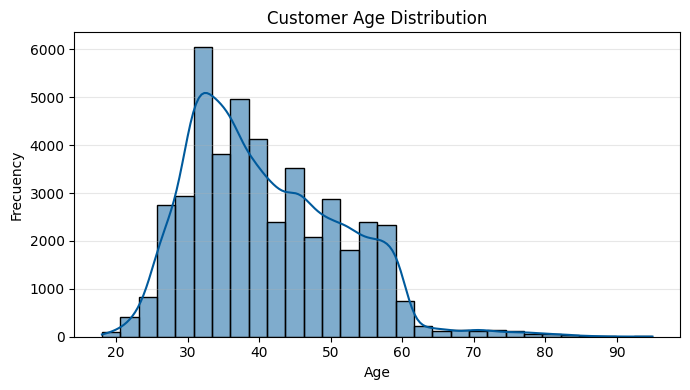

In [15]:
age_pd = df02.select("age").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=age_pd,x="age",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("Age")
plt.title("Customer Age Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/1325750943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_y_pd,x="term_deposit",y="age",order=["yes", "no"],


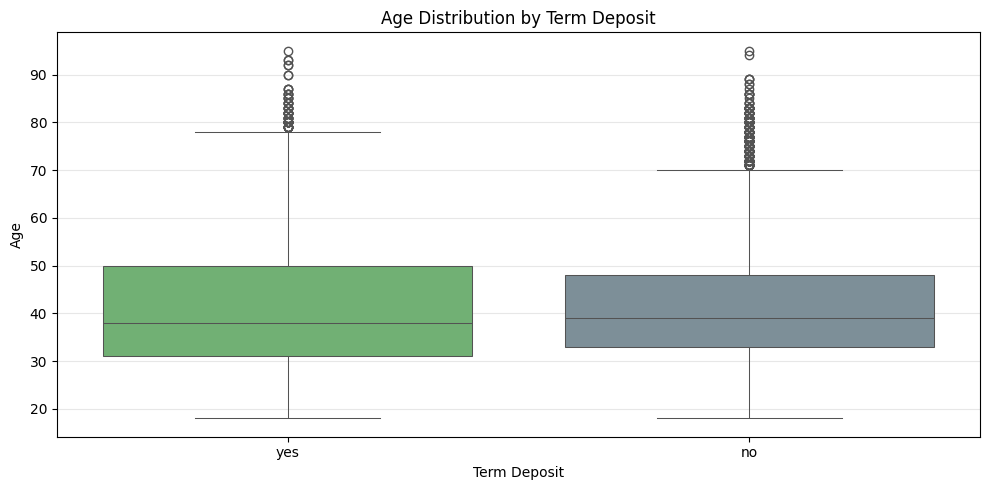

In [16]:
age_y_pd = df02.select("age", "term_deposit").toPandas()
age_y_pd["term_deposit"] = age_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))
sns.boxplot(data=age_y_pd,x="term_deposit",y="age",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Age")
plt.xlabel("Term Deposit")
plt.title("Age Distribution by Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### OBSERVATIONS:
- For the **overall distribution**, the age distribution is right-skewed, with the bulk of customers concentrated between 25 and 45 years old. And, the peak frequency occurs around age 32–33, reaching ~6,000 customers, suggesting the dataset is heavily weighted toward younger adults.
- On the other hand, for the **age distribution by term deposit** the grafic shows that the median age is nearly identical for both groups.
- However, the "yes" group displays a heavier upper tail, suggesting that middle-aged to older customers (50+) are slightly more likely to subscribe to a term deposit.
- And for the "no" group outliers are found after 70 years old.

### 3.1.2. Balance Distribution

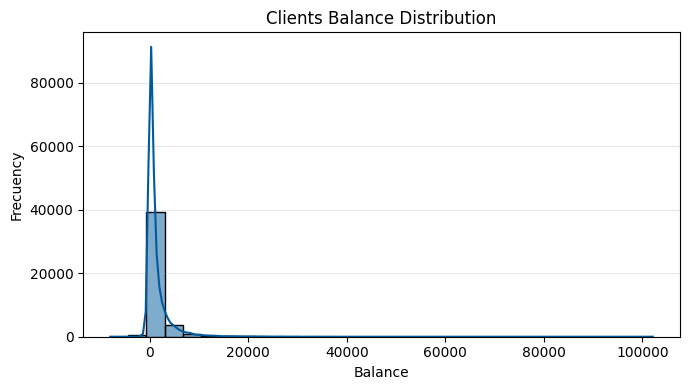

In [17]:
balance_pd = df02.select("balance").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=balance_pd,x="balance",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("Balance")
plt.title("Clients Balance Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/4093068498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balance_y_pd,x="term_deposit",y="balance",order=["yes", "no"],


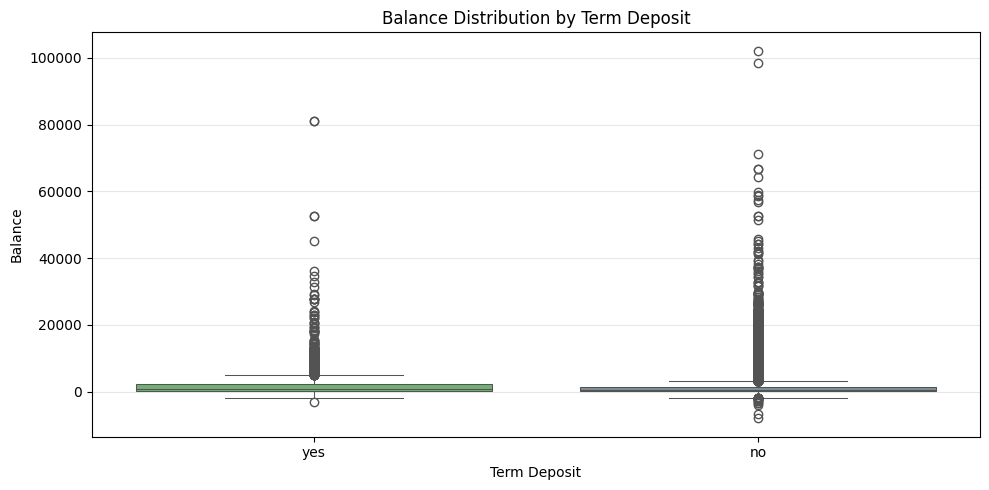

In [18]:
balance_y_pd = df02.select("balance", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
balance_y_pd["term_deposit"] = balance_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=balance_y_pd,x="term_deposit",y="balance",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Balance")
plt.xlabel("Term Deposit")
plt.title("Balance Distribution by Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Comments:
- The vast majority of customers (~90,000+) hold a balance clustered tightly around 0 to ~2,000, making the distribution extremely right-skewed.
- There is a very long right tail extending all the way to ~100,000, but with insignificant frequency — meaning high-balance customers are extremely rare.
- The "yes" group has a noticeably higher median balance than the "no" group, suggesting that customers who subscribe to a term deposit tend to have a higher balance.
- The "no" group has more extreme outliers (up to ~102,000), likely reflecting high-net-worth clients who were contacted but did not want a term deposit.

### 3.1.3. Day Distribution

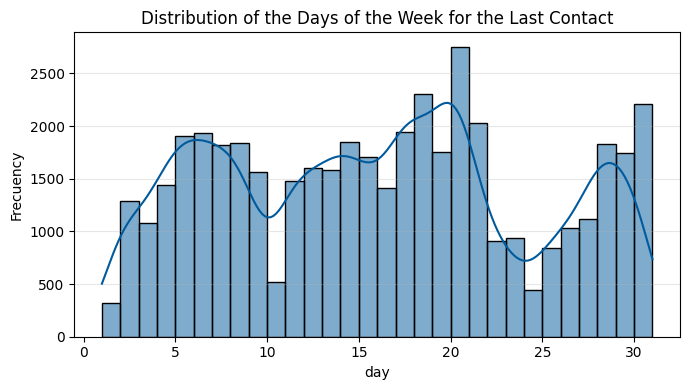

In [19]:
day_pd = df02.select("day").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=day_pd,x="day",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("day")
plt.title("Distribution of the Days of the Week for the Last Contact")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/3946913528.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_y_pd,x="term_deposit",y="day",order=["yes", "no"],


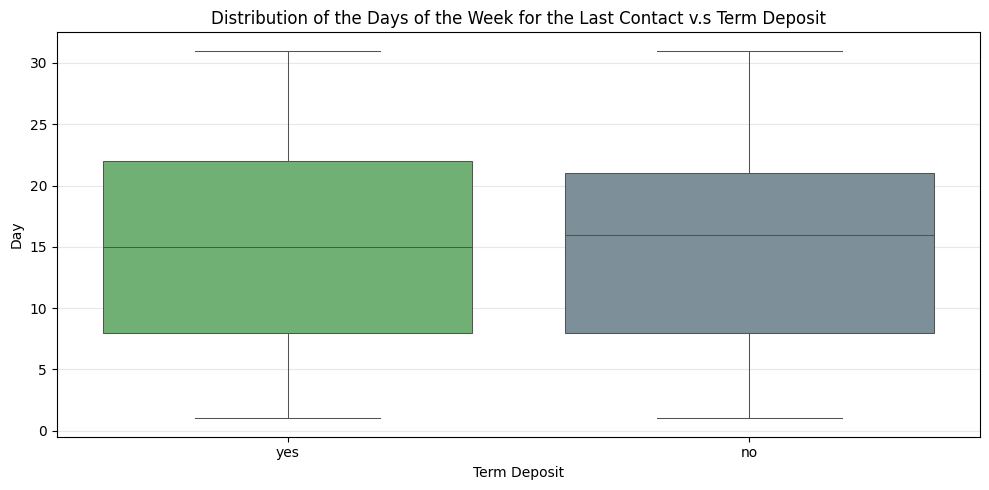

In [20]:
day_y_pd = df02.select("day", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = day_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=day_y_pd,x="term_deposit",y="day",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Day")
plt.xlabel("Term Deposit")
plt.title("Distribution of the Days of the Week for the Last Contact v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Comments:
- Contact activity is not evenly spread — there are three visible surge periods: around days 5–8, days 14–16, and a prominent peak around day 20, which is the single highest frequency bar (~2,750 contacts).
- The two distributions are nearly identical — both groups share virtually the same median (~15–16), the same IQR spread (~9 to ~21–22), and the same whisker range (1 to 31). Also, there are no outliers in either group.

### 3.1.4. Duration Distribution

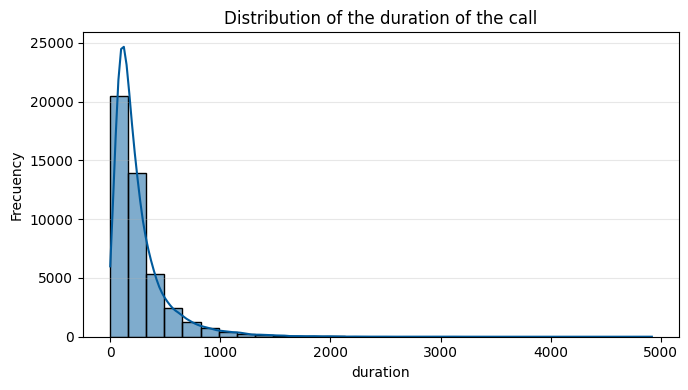

In [21]:
duration_pd = df02.select("duration").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=duration_pd,x="duration",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("duration")
plt.title("Distribution of the duration of the call")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/4212349537.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=duration_y_pd,x="term_deposit",y="duration",order=["yes", "no"],


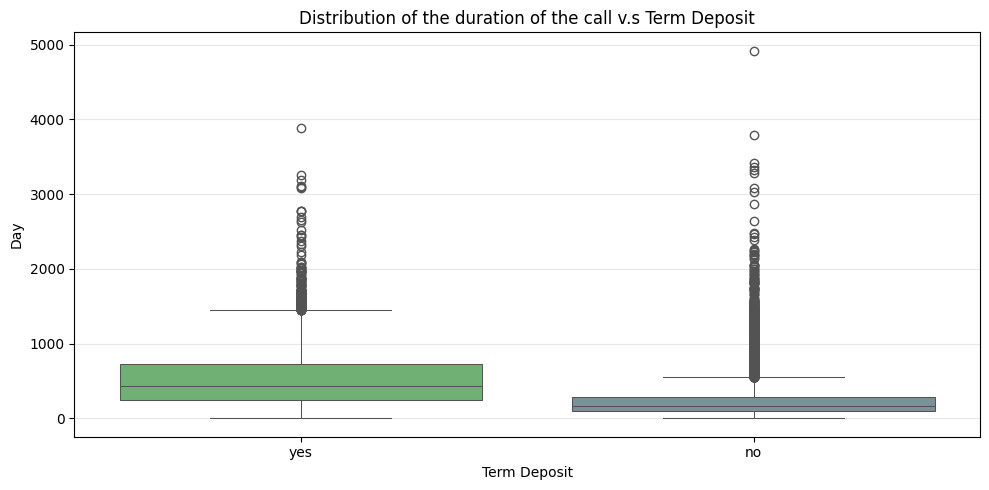

In [22]:
duration_y_pd = df02.select("duration", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = duration_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=duration_y_pd,x="term_deposit",y="duration",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Day")
plt.xlabel("Term Deposit")
plt.title("Distribution of the duration of the call v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Comments:
- The peak frequency occurs in the very first bin (0–100 seconds), with over 20,000 calls, indicating that the majority of contacts are very short calls — likely rejections, hang-ups, or voicemails.
- The entire IQR of the "yes" group sits well above the IQR of the "no" group — there is barely any overlap at the box level.
- Both groups have outliers, but the "no" group's extreme outlier (~4,900 sec) likely represents edge cases where a long call still did not result in a subscription.

### 3.1.5. Campaign Distribution

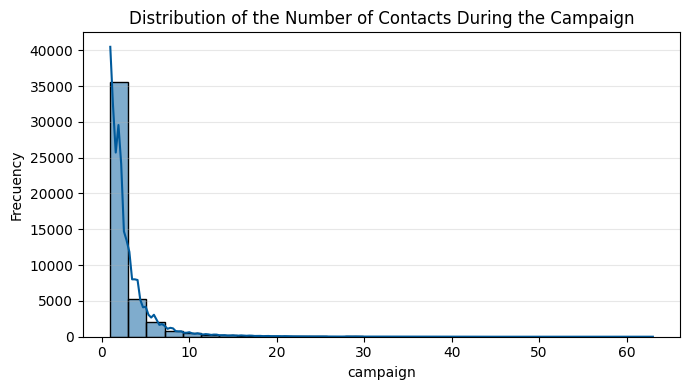

In [23]:
campaign_pd = df02.select("campaign").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=campaign_pd,x="campaign",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("campaign")
plt.title("Distribution of the Number of Contacts During the Campaign")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/2550810183.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=campaign_y_pd,x="term_deposit",y="campaign",order=["yes", "no"],


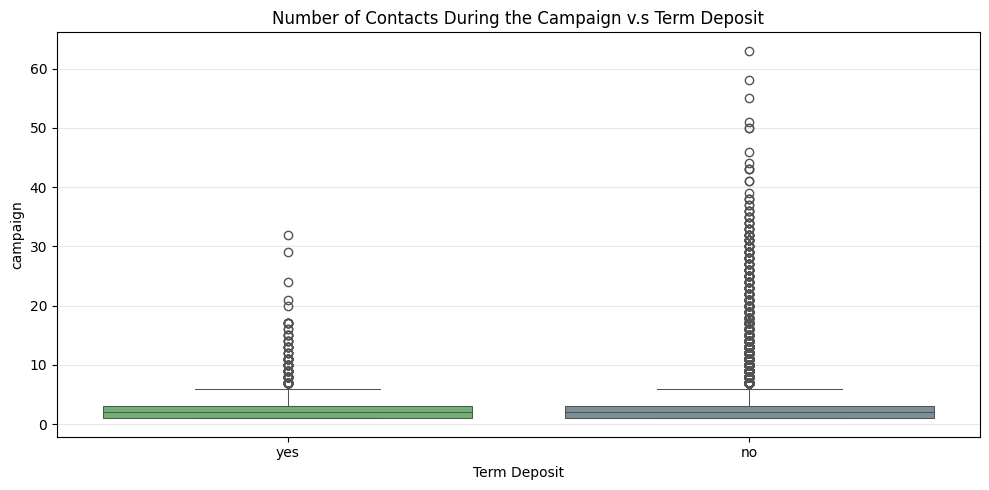

In [24]:
campaign_y_pd = df02.select("campaign", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = campaign_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=campaign_y_pd,x="term_deposit",y="campaign",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("campaign")
plt.xlabel("Term Deposit")
plt.title("Number of Contacts During the Campaign v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Comments:
- The overwhelming majority of customers were contacted only 1 or 2 times, with the first two bins accounting for well over 70,000 records combined.
- The most telling difference lies in the outliers: the "no" group has far more extreme cases (up to 63 contacts), while the "yes" group tops out around 32. This suggests that customers who were contacted excessively almost never converted

### 3.1.6. Pdays Distribution 

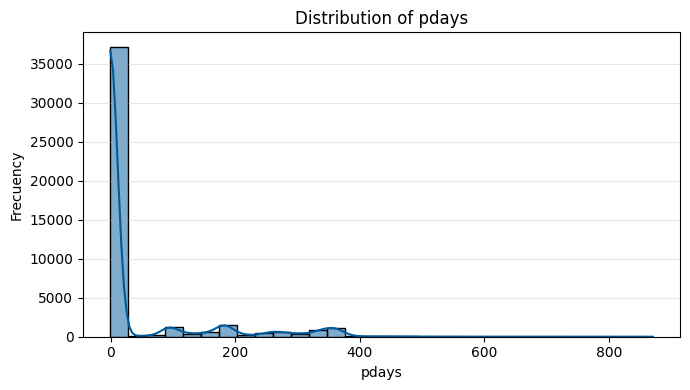

In [25]:
pdays_pd = df02.select("pdays").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=pdays_pd,x="pdays",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("pdays")
plt.title("Distribution of pdays")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/2050968714.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdays_y_pd,x="term_deposit",y="pdays",order=["yes", "no"],


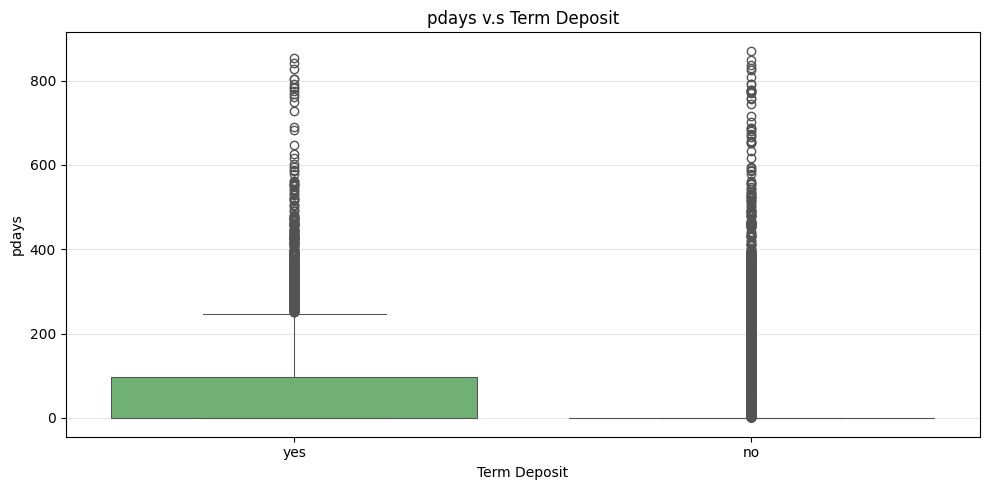

In [26]:
pdays_y_pd = df02.select("pdays", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = pdays_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=pdays_y_pd,x="term_deposit",y="pdays",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("pdays")
plt.xlabel("Term Deposit")
plt.title("pdays v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Comments:
- The "no" group has its entire box collapsed at zero — meaning virtually all non-subscribers were never previously contacted, with all non-zero values appearing as outliers.

### 3.1.7. Previous Distribution 

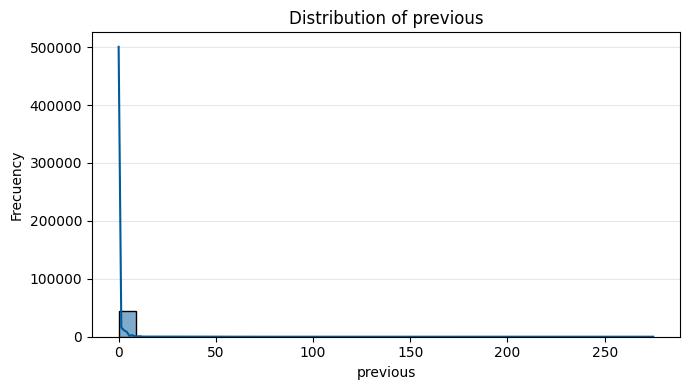

In [27]:
previous_pd = df02.select("previous").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=previous_pd,x="previous",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("previous")
plt.title("Distribution of previous")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/3750700691.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=previous_y_pd,x="term_deposit",y="previous",order=["yes", "no"],


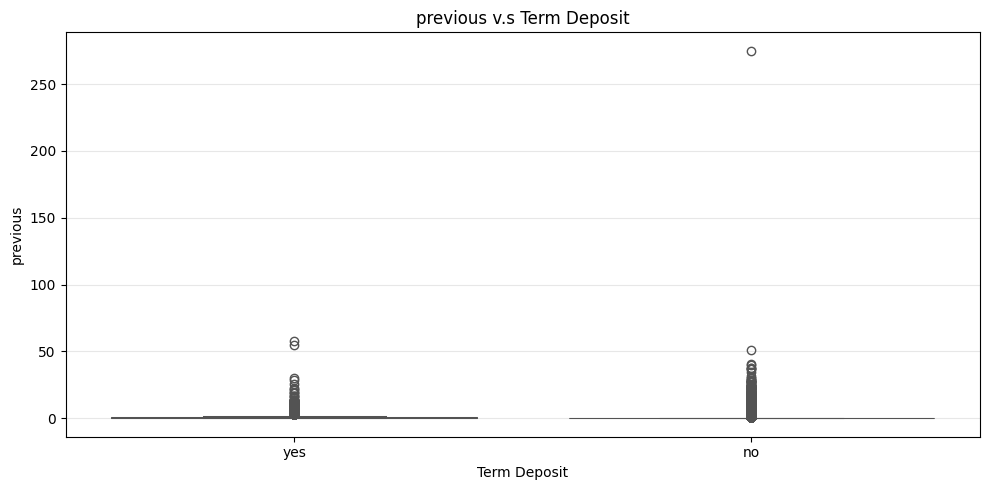

In [28]:
previous_y_pd = df02.select("previous", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = previous_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=previous_y_pd,x="term_deposit",y="previous",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("previous")
plt.xlabel("Term Deposit")
plt.title("previous v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Comments:
- The spike at 0 dominates entirely, reaching ~500,000 frequency — meaning the vast majority of customers had zero prior contacts before this campaign. This is consistent with what was observed in pdays.
- Both boxes are completely collapsed at zero, confirming that the median and IQR are essentially 0 for both groups.

## 3.2. Correlation

To analyze the linear relationship between the numerical features and the target variable, 
a subset of the dataset was created containing only the integer columns along with `term_deposit`.

Since `term_deposit` is a categorical variable (`"yes"` / `"no"`), it was re-encoded 
as a binary integer so it can participate in numerical correlation calculations:

- `"yes"` → `1`  
- `"no"` → `0`

In [29]:
colINT=['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [30]:
dfauxNum = df02.select(colINT+['term_deposit'])
# for the variable term_deposit we change the values.
dfauxNum = dfauxNum.withColumn('term_deposit', F.when(dfauxNum['term_deposit'] == "yes",1).otherwise(0))
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+------------+
|age|balance|day|duration|campaign|pdays|previous|term_deposit|
+---+-------+---+--------+--------+-----+--------+------------+
| 58|   2143|  5|     261|       1|   -1|       0|           0|
| 44|     29|  5|     151|       1|   -1|       0|           0|
| 33|      2|  5|      76|       1|   -1|       0|           0|
| 47|   1506|  5|      92|       1|   -1|       0|           0|
| 33|      1|  5|     198|       1|   -1|       0|           0|
+---+-------+---+--------+--------+-----+--------+------------+
only showing top 5 rows



PySpark's `Correlation` module requires the data to be in a single vector column. 
A `VectorAssembler` was used to combine all numerical columns (including the encoded 
`term_deposit`) into a single `features` column. This step also normalizes and scales the data representation, which is necessary for computing a valid Pearson correlation matrix.

In [31]:
# we change the auxiliar dataframe into a VectorAssembler of 'feature'
# the idea is to create the correlation matrix with the vector so that the variables are normalized
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

assembler = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
#normalized and scalated
dfNumVector = assembler.transform(dfauxNum).select('features')


The Pearson correlation matrix was computed using PySpark's `Correlation.corr()` method, 
then converted to a pandas DataFrame for visualization:

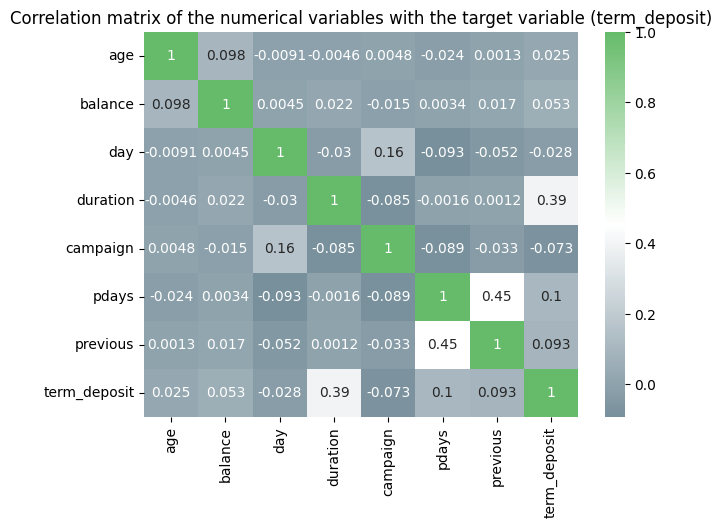

In [32]:
from matplotlib.colors import LinearSegmentedColormap
matrixCorr = Correlation.corr(dfNumVector, 'features').head()
vectorCorr = matrixCorr[0].toArray()
dfCorrelation = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

# generate a custom diverging colormap
cmapMejia = LinearSegmentedColormap.from_list(
    "cmapMejia", 
    ["#78909C", "#FFFFFF", "#66BB6A"]  # no → blanco → yes
)
plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapMejia)
plt.title("Correlation matrix of the numerical variables with the target variable (term_deposit)")
plt.show()

#### Comments:
- In general, most numerical variables show very low correlation with each other, 
suggesting they are largely **independent features**. This is a favorable condition 
for training a predictive model, as it reduces multicollinearity concerns.
- `duration` shows the **strongest correlation with `term_deposit`** (r = 0.39), which means it has to be deleted.
- `pdays` (days since last contact in a previous campaign) and `previous` (number of 
contacts in previous campaigns) show a **moderate correlation between themselves** 
(r = 0.45). Both variables show a **low but positive correlation with `term_deposit`** (r = 0.1 and r = 0.093 
respectively), suggesting they carry **some predictive signal** — clients with prior 
contact history may be slightly more inclined to subscribe. 
- `campaign` (number of contacts during the current campaign) shows a **negative 
correlation with `term_deposit`** (r = -0.073). This suggests that clients who are 
contacted **more times** during the current campaign are *less* likely to subscribe to 
a term deposit

## 3.3. Pairplot Analysis
The pairplot displays the pairwise relationships between all numerical variables,
color-coded by the target variable: **blue = 0 (no subscription)**, 
**green = 1 (subscription)**. This visualization complements the correlation 
matrix by revealing distributional patterns and class separation that linear 
correlation alone cannot capture.

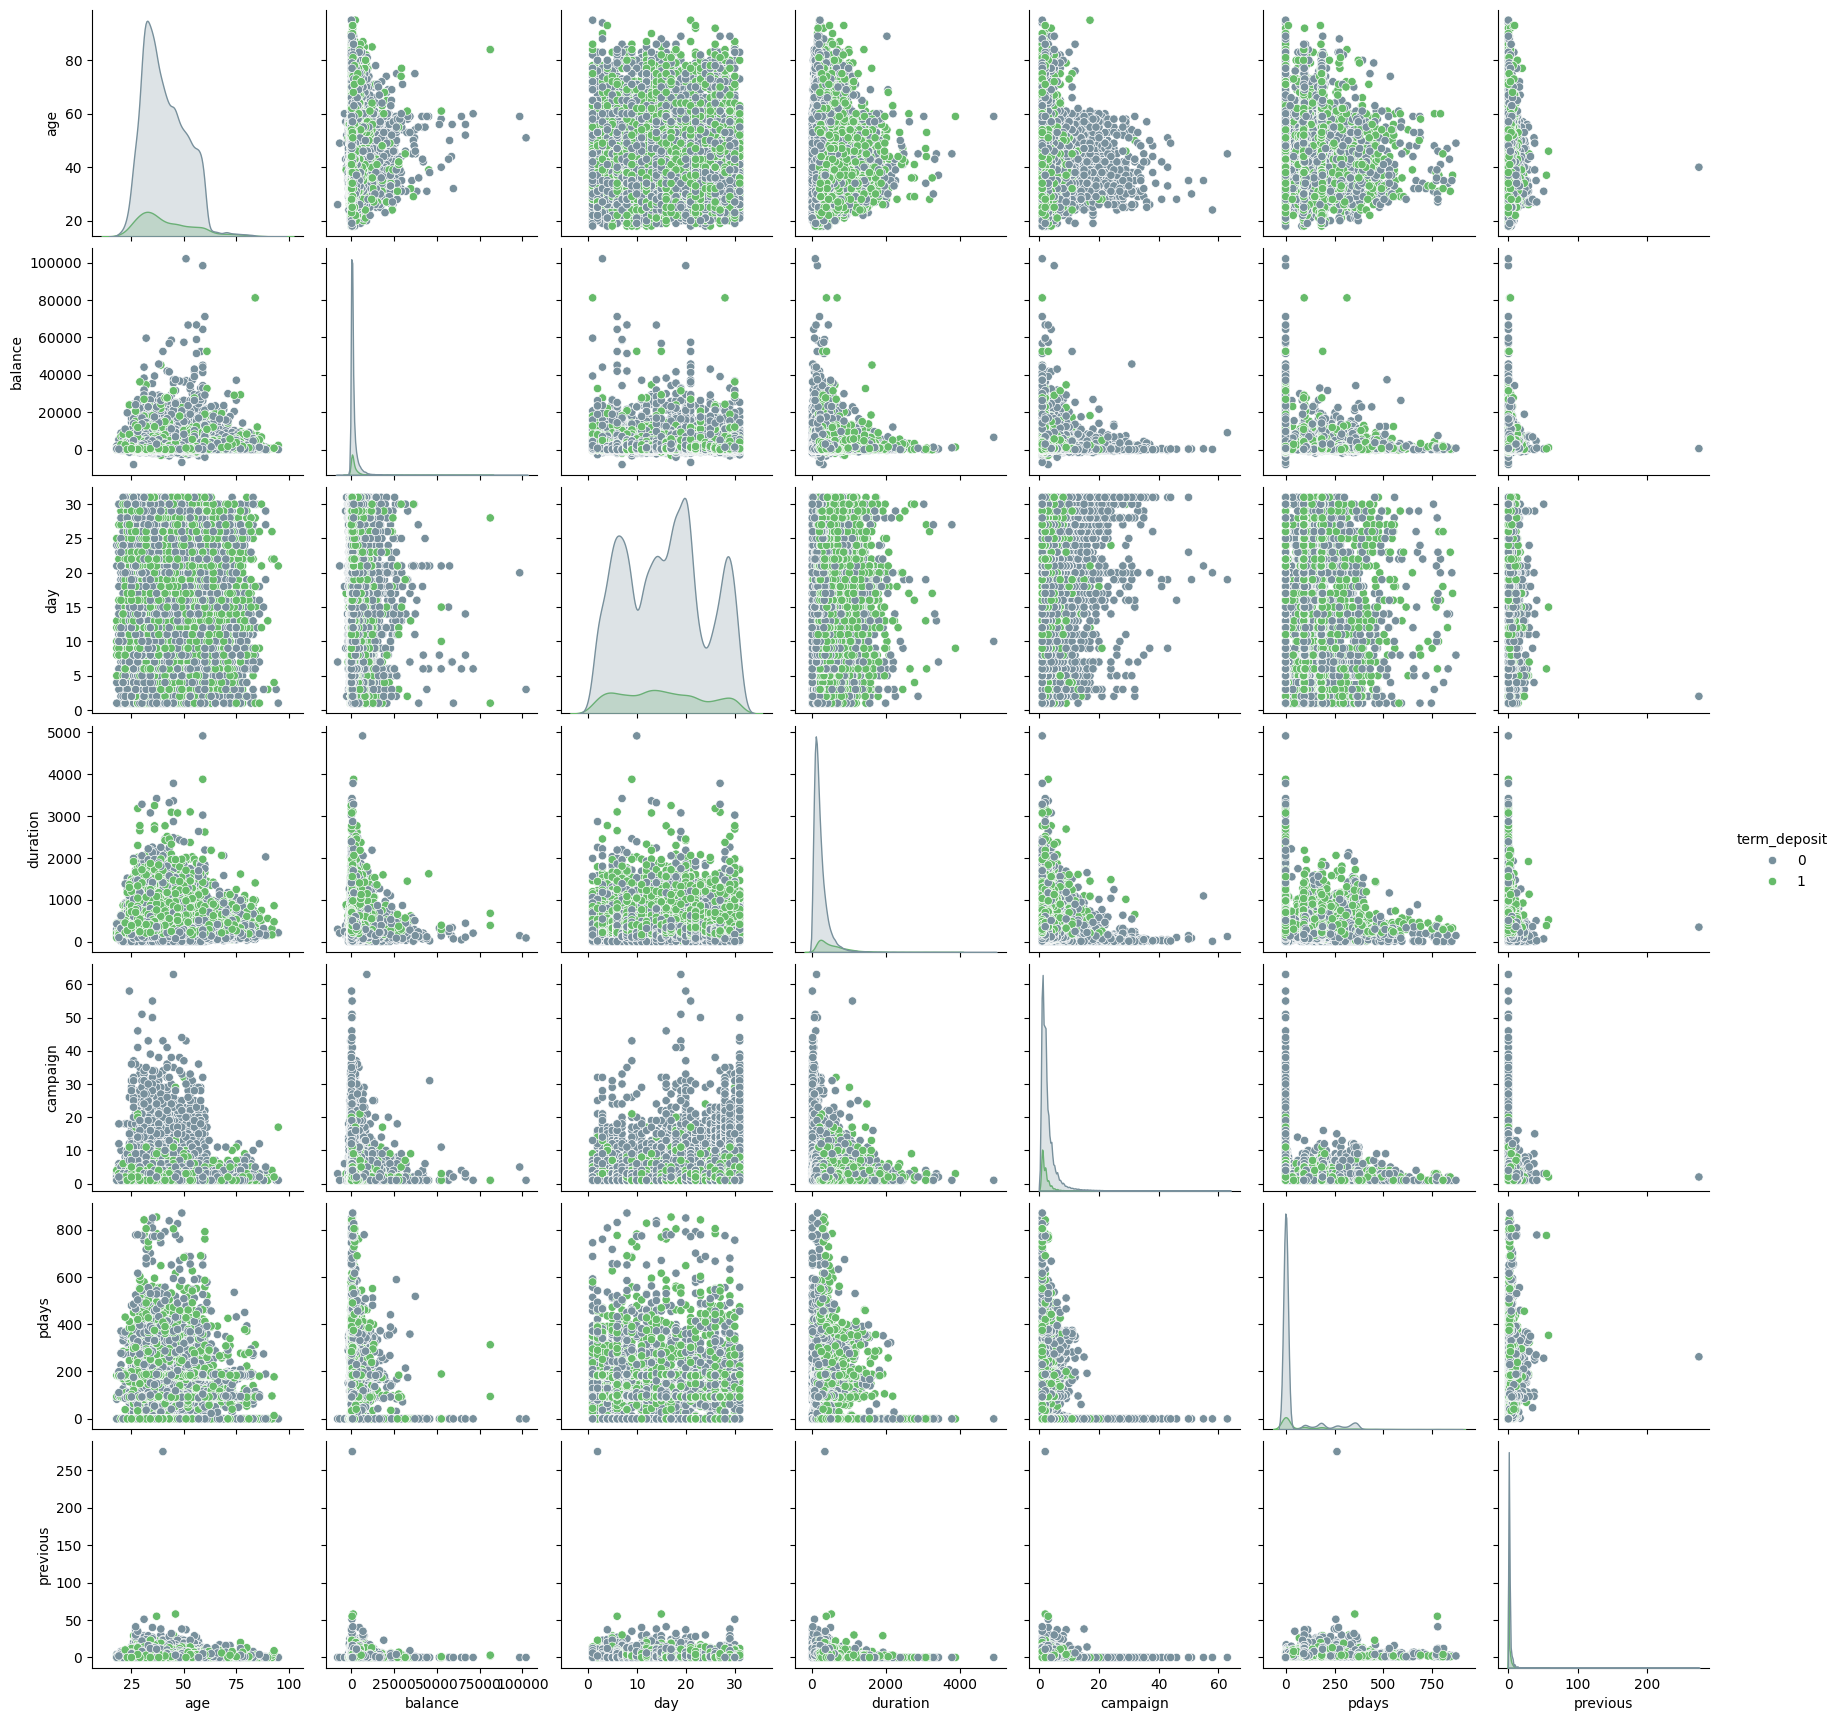

In [33]:
colors = ["#78909C", "#66BB6A"]
palette = {0: colors[0], 1: colors[1]}

sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='term_deposit', palette=palette)
plt.show()

#### `duration` — Confirms removal
The diagonal KDE for `duration` shows a clear distributional difference between classes: clients who subscribed (orange) tend to have **longer call durations**, which visually confirms the high correlation (r = 0.39) found in the matrix. This reinforces the decision to **remove this variable** — it is a direct consequence of the outcome, not a true predictor available before the call.

---

#### `campaign` — Confirms negative influence
In the scatterplots involving `campaign`, orange dots (subscribers) are heavily concentrated at **low contact counts (1–5 calls)**, while blue dots (non-subscribers) spread across much higher values. This visually supports the **negative correlation** found (r = -0.073): over-contacting clients during the current campaign is associated with lower subscription likelihood.

---

#### `pdays` and `previous` — Sparse but informative
Both variables show **highly skewed distributions** in their diagonal KDEs, with the vast majority of observations concentrated near zero. This is explained by the large number of clients who were **never previously contacted** (`pdays = -1` as placeholder, `previous = 0`).

## 3.4. Distribution of Binary Variables

### 3.4.1. Default Distribution

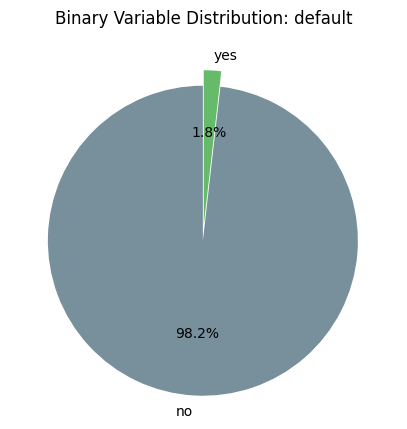

In [34]:
explode = (0.1, 0)
colors = ["#78909C", "#66BB6A"]

plt.figure(figsize=(5,6))
cantBin = df02.groupby('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Binary Variable Distribution: default')
plt.ylabel('')
plt.show()

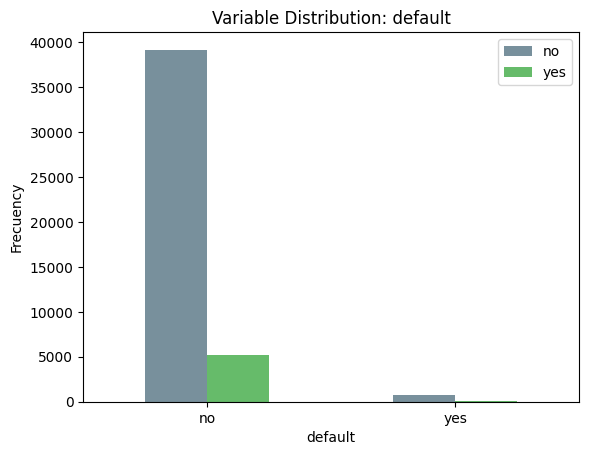

In [35]:
cratabJob = df02.crosstab('default', 'term_deposit').toPandas()
cratabJob.set_index('default'+'_term_deposit').plot(kind='bar', color=['#78909C', '#66BB6A'])
plt.xlabel('default')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: default')
plt.xticks(rotation=0)
plt.show()

#### Comments:
- Credit in default means a borrower has failed to meet their debt obligations — they haven't made required payments for an extended period.
- The vast majority of clients (98.2%) have no credit in default, while only 1.8% do have credit in default.
- Clients with default almost never subscribe to a term deposit (~50 cases)

### 3.4.2. Housing Distribution

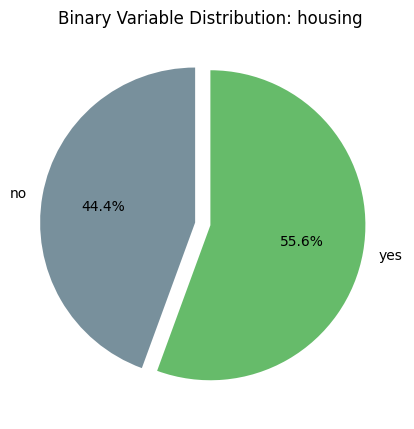

In [36]:
explode = (0.1, 0)
colors = ['#78909C', '#66BB6A']

plt.figure(figsize=(5,6))
cantBin = df02.groupby('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Binary Variable Distribution: housing')
plt.ylabel('')
plt.show()

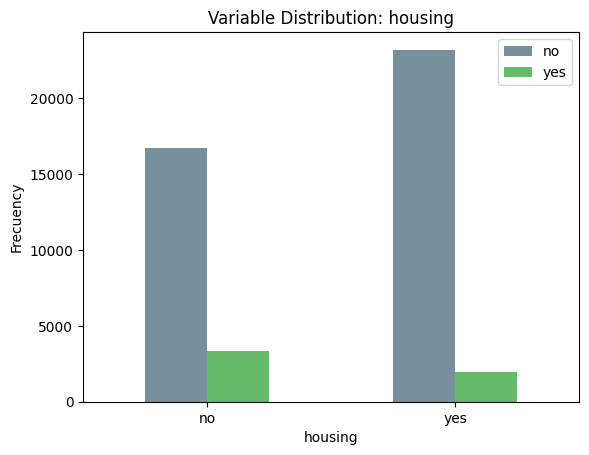

In [37]:
cratabJob = df02.crosstab('housing', 'term_deposit').toPandas()
cratabJob.set_index('housing'+'_term_deposit').plot(kind='bar', color = ['#78909C', '#66BB6A'])
plt.xlabel('housing')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: housing')
plt.xticks(rotation=0)
plt.show()

#### Comments:
- Represents if the client has a housing loan. This variable is mostly balanced.
- Most of the clients that have a housing loan (yes) do not have a term deposit. This suggests that financial flexibility (no mortgage burden) encourages investment in term deposits
- Clients without a housing loan are roughly twice as likely to subscribe to a term deposit

### 3.4.3. Loan Distribution

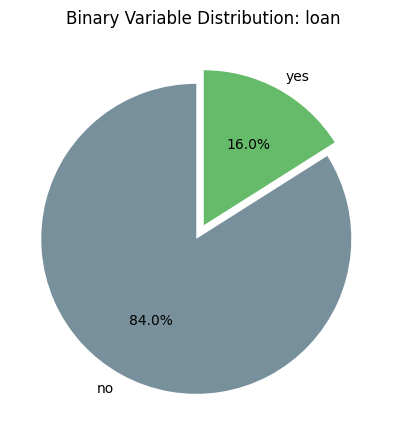

In [38]:
explode = (0.1, 0)
colors = ['#78909C', '#66BB6A']

plt.figure(figsize=(5,6))
cantBin = df02.groupby('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Binary Variable Distribution: loan')
plt.ylabel('')
plt.show()

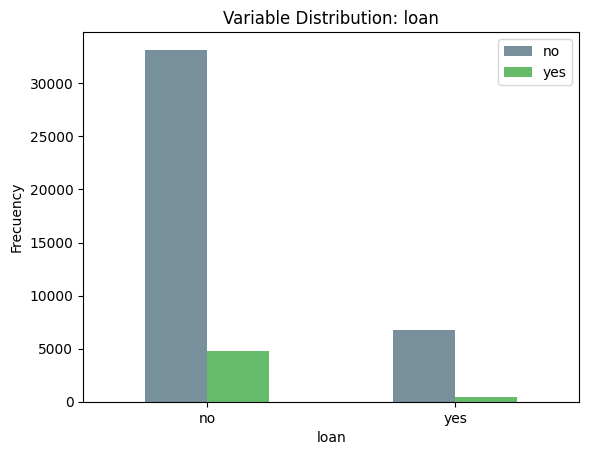

In [39]:
cratabJob = df02.crosstab('loan', 'term_deposit').toPandas()
cratabJob.set_index('loan'+'_term_deposit').plot(kind='bar', color = ['#78909C', '#66BB6A'])
plt.xlabel('loan')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: loan')
plt.xticks(rotation=0)
plt.show()

#### Comments:
- For this dataset, the mayority of the clients do not have a personal loan. That is why the quantity of clients with a personal loan and a term deposit is insignificant in comparison with the clients that do not have a personal loan but have a term deposit. 

## 3.5. Distribution of Categorical Variables

### 3.5.1. Job Distribution

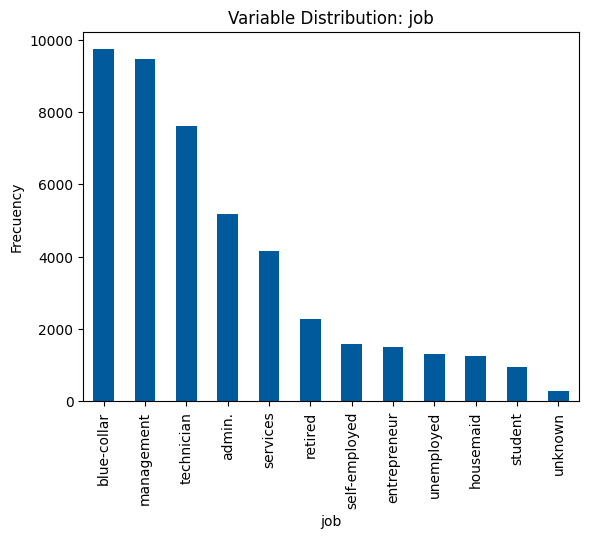

In [40]:
cantMulti = df02.groupby('job').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='job', y='count', legend=None, color="#005A9C")
plt.xlabel('job')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: job')
plt.show()

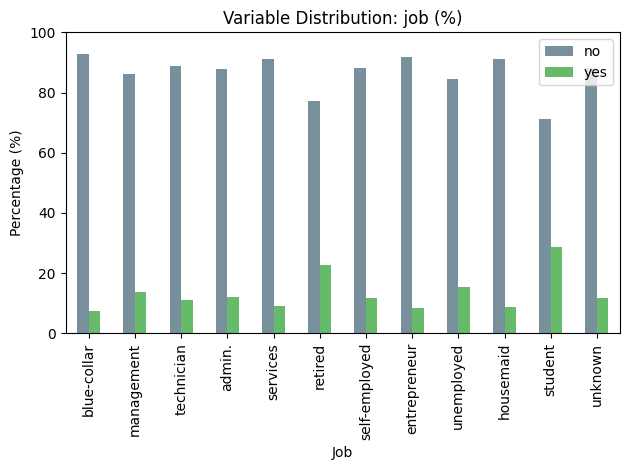

In [41]:
cratabJob = df02.crosstab('job', 'term_deposit').toPandas()
cratabJob['total'] = cratabJob.iloc[:, 1:].sum(axis=1)
cratabJob = cratabJob.sort_values('total', ascending=False).drop(columns='total')

# Convert to percentages
cratabJob_pct = cratabJob.copy()
cratabJob_pct['total'] = cratabJob_pct.iloc[:, 1:].sum(axis=1)
cratabJob_pct['no']  = cratabJob_pct['no']  / cratabJob_pct['total'] * 100
cratabJob_pct['yes'] = cratabJob_pct['yes'] / cratabJob_pct['total'] * 100
cratabJob_pct = cratabJob_pct.drop(columns='total')

# Plot
cratabJob_pct.set_index('job_term_deposit').plot(kind='bar', color=['#78909C', '#66BB6A'])
plt.xlabel('Job')
plt.ylabel('Percentage (%)')
plt.title('Variable Distribution: job (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### Comments:
- Eventhough the frecuency of students in the dataset is less than 2000. Meaning that there aren't so many, this should be one of the target populations because students and retired clients have the highest subscription rates despite being small groups.

### 3.5.2. Marital Distribution

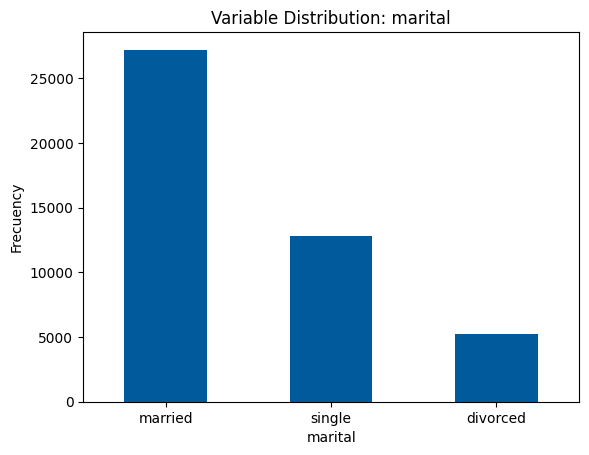

In [42]:
cantMulti = df02.groupby('marital').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='marital', y='count', legend=None, color="#005A9C")
plt.xlabel('marital')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: marital')
plt.xticks(rotation=0)
plt.show()

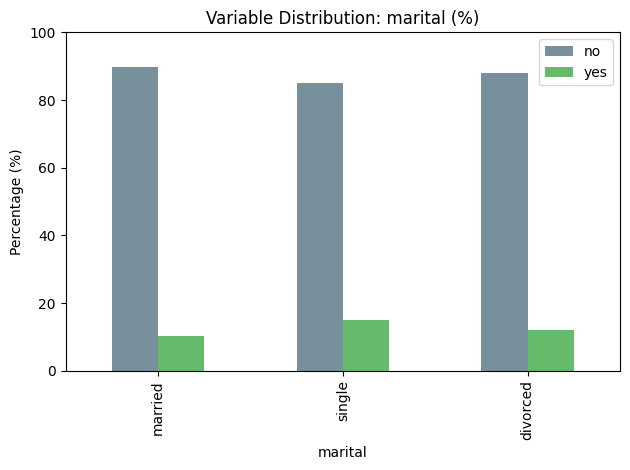

In [105]:
cratabMarital = df02.crosstab('marital', 'term_deposit').toPandas()
cratabMarital['total'] = cratabMarital.iloc[:, 1:].sum(axis=1)
cratabMarital = cratabMarital.sort_values('total', ascending=False).drop(columns='total')

# Convert to percentages
cratabMarital_pct = cratabMarital.copy()
cratabMarital_pct['total'] = cratabMarital_pct.iloc[:, 1:].sum(axis=1)
cratabMarital_pct['no']  = cratabMarital_pct['no']  / cratabMarital_pct['total'] * 100
cratabMarital_pct['yes'] = cratabMarital_pct['yes'] / cratabMarital_pct['total'] * 100
cratabMarital_pct = cratabMarital_pct.drop(columns='total')

# Plot
cratabMarital_pct.set_index('marital'+'_term_deposit').plot(kind='bar', color = ['#78909C', '#66BB6A'])
plt.xlabel('marital')
plt.ylabel('Percentage (%)')
plt.title('Variable Distribution: marital (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### Comments:
- The dataset is dominated by **married clients (~27,000)**, followed by single (~13,000) and divorced (~5,200). This reflects a typical adult banking population where married individuals form the majority.
- Despite **married clients being the largest group**, they show the **lowest ubscription rate (~10%)** among the three categories. 
- **Single clients** show the **highest subscription rate (~15%)**, suggesting they may be more financially flexible or open to investment products — possibly due to fewer financial commitments compared to married clients.
- **Divorced clients** fall in between (~12%), closer to the married group than to the single group.

### 3.5.3. Education Distribution

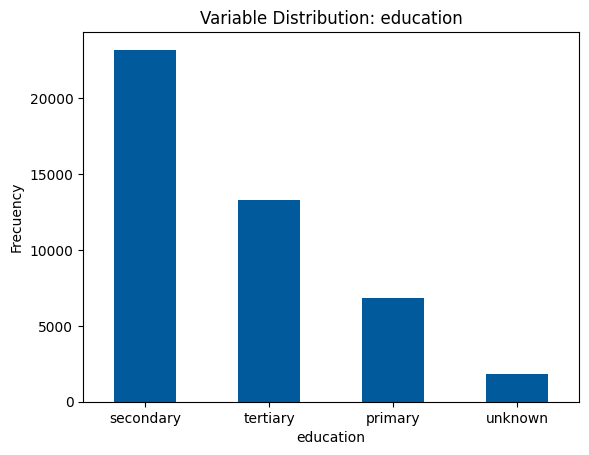

In [44]:
cantMulti = df02.groupby('education').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='education', y='count', legend=None, color="#005A9C")
plt.xlabel('education')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: education')
plt.xticks(rotation=0)
plt.show()

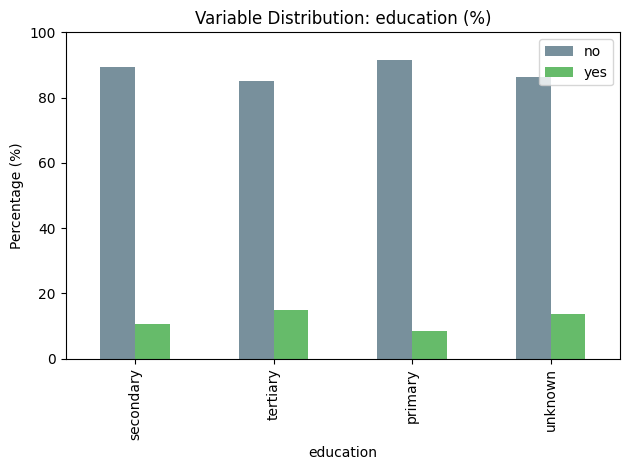

In [108]:
cratabEducation = df02.crosstab('education', 'term_deposit').toPandas()
cratabEducation['total'] = cratabEducation.iloc[:, 1:].sum(axis=1)
cratabEducation = cratabEducation.sort_values('total', ascending=False).drop(columns='total')

# Convert to percentages
cratabEducation_pct = cratabEducation.copy()
cratabEducation_pct['total'] = cratabEducation_pct.iloc[:, 1:].sum(axis=1)
cratabEducation_pct['no']  = cratabEducation_pct['no']  / cratabEducation_pct['total'] * 100
cratabEducation_pct['yes'] = cratabEducation_pct['yes'] / cratabEducation_pct['total'] * 100
cratabEducation_pct = cratabEducation_pct.drop(columns='total')

# Plot
cratabEducation_pct.set_index('education'+'_term_deposit').plot(kind='bar', color = ['#78909C', '#66BB6A'])
plt.xlabel('education')
plt.ylabel('Percentage (%)')
plt.title('Variable Distribution: education (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### Comments:
- **Secondary** is the dominant education level with ~23,000 clients, representing over half the dataset.
- **Secondary** educated clients subscribe at ~10%, close to the overall dataset average.
- **Tertiary** educated clients show the **highest subscription rate (~15%)**, suggesting that higher education levels correlate with greater interest in financial investment products.
- **Unknown** sits at ~14%, surprisingly close to tertiary — this group may contain clients with higher education that was simply not recorded.
- **Primary** educated clients show the **lowest subscription rate (~8%)**, which may reflect lower financial literacy or disposable income available for term deposits.

### 3.5.4. Contact Distribution

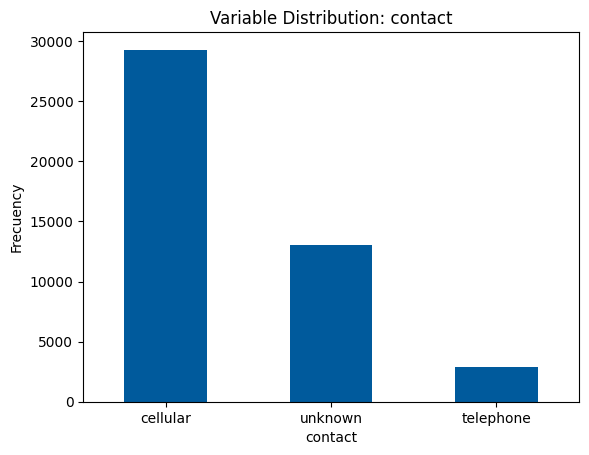

In [46]:
cantMulti = df02.groupby('contact').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='contact', y='count', legend=None, color="#005A9C")
plt.xlabel('contact')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: contact')
plt.xticks(rotation=0)
plt.show()

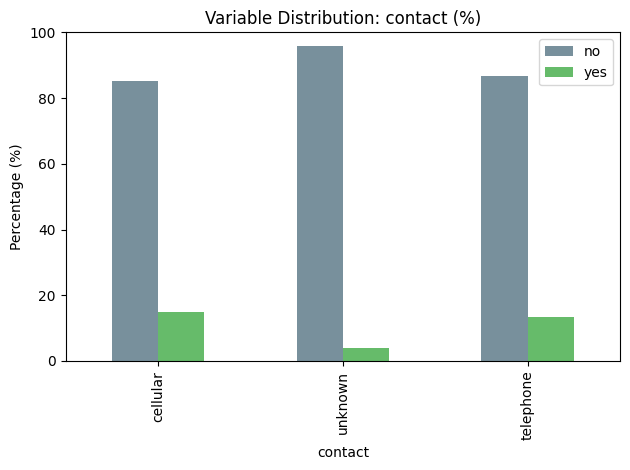

In [109]:
cratabContact = df02.crosstab('contact', 'term_deposit').toPandas()
cratabContact['total'] = cratabContact.iloc[:, 1:].sum(axis=1)
cratabContact = cratabContact.sort_values('total', ascending=False).drop(columns='total')

# Convert to percentages
cratabContact_pct = cratabContact.copy()
cratabContact_pct['total'] = cratabContact_pct.iloc[:, 1:].sum(axis=1)
cratabContact_pct['no']  = cratabContact_pct['no']  / cratabContact_pct['total'] * 100
cratabContact_pct['yes'] = cratabContact_pct['yes'] / cratabContact_pct['total'] * 100
cratabContact_pct = cratabContact_pct.drop(columns='total')

# Plot
cratabContact_pct.set_index('contact'+'_term_deposit').plot(kind='bar', color = ['#78909C', '#66BB6A'])
plt.xlabel('contact')
plt.ylabel('Percentage (%)')
plt.title('Variable Distribution: contact (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### Comments:
- **Cellular** is by far the most common contact method with ~29,000 clients, representing nearly two thirds of the dataset.
- **Cellular** contacts show the **highest subscription rate (~15%)**, suggesting that clients reached by mobile phone are more responsive and engaged with the campaign.
- **Unknown** is the second largest group with ~13,000 clients — a significant portion of the data where the contact method was not recorded.
- **Unknown** contacts show the **lowest subscription rate (~4%)**, which is strikingly low compared to the other two categories — clients with no recorded contact method were almost never converted.
- **Telephone** contacts subscribe at ~13%, slightly lower than cellular but still moderate.

> The `unknown` category is particularly notable: its very low subscription 
> rate (~4%) combined with its large size (~13,000 records) may reflect clients 
> who were **not effectively reached** during the campaign. The contact method 
> appears to be a **strong predictor** — cellular contact is clearly associated 
> with better campaign outcomes and should carry significant weight in the model.

### 3.5.5. Month Distribution

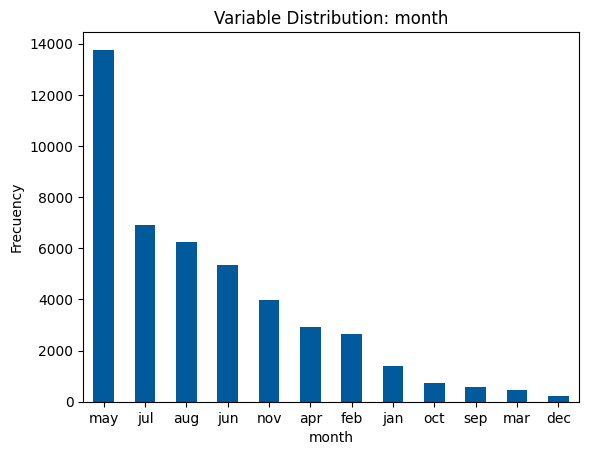

In [48]:
cantMulti = df02.groupby('month').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='month', y='count', legend=None, color="#005A9C")
plt.xlabel('month')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: month')
plt.xticks(rotation=0)
plt.show()

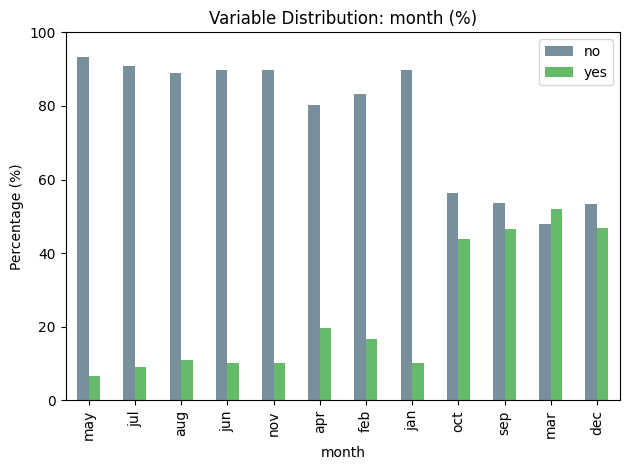

In [111]:
cratabMonth = df02.crosstab('month', 'term_deposit').toPandas()
cratabMonth['total'] = cratabMonth.iloc[:, 1:].sum(axis=1)
cratabMonth = cratabMonth.sort_values('total', ascending=False).drop(columns='total')

# Convert to percentages
cratabMonth_pct = cratabMonth.copy()
cratabMonth_pct['total'] = cratabMonth_pct.iloc[:, 1:].sum(axis=1)
cratabMonth_pct['no']  = cratabMonth_pct['no']  / cratabMonth_pct['total'] * 100
cratabMonth_pct['yes'] = cratabMonth_pct['yes'] / cratabMonth_pct['total'] * 100
cratabMonth_pct = cratabMonth_pct.drop(columns='total')

# Plot
cratabMonth_pct.set_index('month'+'_term_deposit').plot(kind='bar', color = ['#78909C', '#66BB6A'])
plt.xlabel('month')
plt.ylabel('Percentage (%)')
plt.title('Variable Distribution: month (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### Comments
- **May** is by far the most active campaign month with ~13,800 contacts, nearly double the second busiest month.
- **July (~7,000), August (~6,300) and June (~5,400)** form a second tier, suggesting the campaign is most heavily executed during **spring and summer**.
- **November (~4,000), April (~3,000) and February (~2,600)** represent moderate activity months.
- **January, October, September, March and December** are the least active months, with December being the quietest (~250 contacts).

---
**Distribution vs. Target Variable (`term_deposit`)**

- **March, September, October and December** stand out with the **highest subscription rates (~44-47%)**, nearly half of all contacts in those months converting — a striking contrast to the rest of the year.
- **April (~20%) and February (~16%)** also show above-average subscription rates compared to the summer months.
- **May (~6%)** has the **lowest subscription rate** despite being the most contacted month — the sheer volume of calls in May does not translate into conversions, suggesting possible **campaign fatigue or poor targeting** during peak activity.
- **July, August, June, November and January** all cluster around **9-11%**, representing average performance months.

### 3.5.6. Performance Distribution

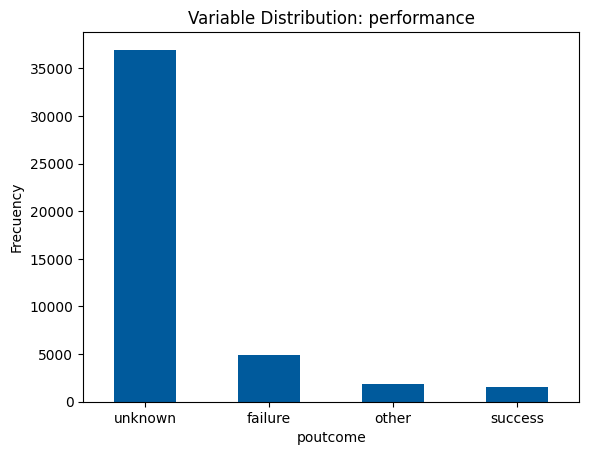

In [50]:
cantMulti = df02.groupby('poutcome').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
cantMulti.plot(kind='bar', x='poutcome', y='count', legend=None, color="#005A9C")
plt.xlabel('poutcome')
plt.ylabel('Frecuency')
plt.title(f'Variable Distribution: performance')
plt.xticks(rotation=0)
plt.show()

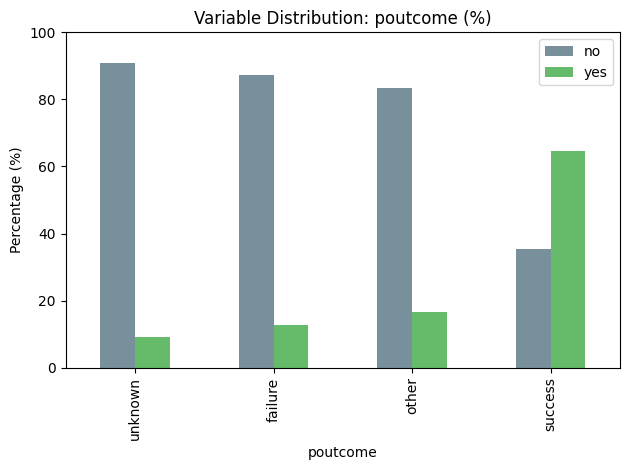

In [112]:
cratabPoutcome = df02.crosstab('poutcome', 'term_deposit').toPandas()
cratabPoutcome['total'] = cratabPoutcome.iloc[:, 1:].sum(axis=1)
cratabPoutcome = cratabPoutcome.sort_values('total', ascending=False).drop(columns='total')

# Convert to percentages
cratabPoutcome_pct = cratabPoutcome.copy()
cratabPoutcome_pct['total'] = cratabPoutcome_pct.iloc[:, 1:].sum(axis=1)
cratabPoutcome_pct['no']  = cratabPoutcome_pct['no']  / cratabPoutcome_pct['total'] * 100
cratabPoutcome_pct['yes'] = cratabPoutcome_pct['yes'] / cratabPoutcome_pct['total'] * 100
cratabPoutcome_pct = cratabPoutcome_pct.drop(columns='total')

# Plot
cratabPoutcome_pct.set_index('poutcome'+'_term_deposit').plot(kind='bar', color = ['#78909C', '#66BB6A'])
plt.xlabel('poutcome')
plt.ylabel('Percentage (%)')
plt.title('Variable Distribution: poutcome (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

#### Comments:
- **Unknown (~37,000)** dominates the dataset overwhelmingly, confirming the earlier finding that the vast majority of clients had **no prior campaign contact**.
- **Failure (~5,000)** is the second largest group — clients who were contacted in a previous campaign but did not subscribe.
- **Other (~2,000)** and **Success (~1,600)** are the smallest groups, with success being the rarest recorded outcome.

---

**Distribution vs. Target Variable (`term_deposit`)**

- **Success** is the **strongest signal in the entire dataset** — clients whose previous campaign outcome was a success subscribe at an extraordinary **~65% rate**, meaning nearly 2 out of 3 previously successful clients subscribe again.
- **Other (~17%)** and **Failure (~13%)** show modest but above-average subscription rates compared to the overall dataset baseline.
- **Unknown (~9%)** has the lowest subscription rate, consistent with the lack of prior engagement history.

## 3.6. Extra Graphs

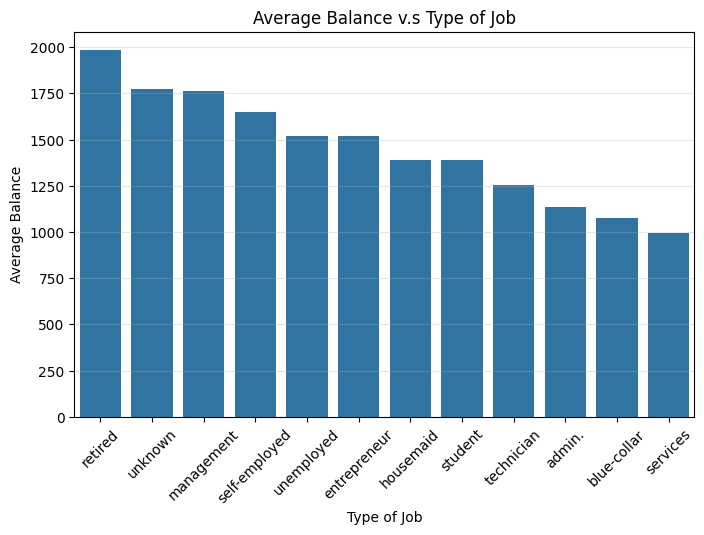

In [52]:
colNames = ['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'term_deposit']
## graph relationship between balance and job type
balance = df02.groupBy('job').agg({'balance':'mean'}).toPandas()
## the average balance and the type of job are organized from highest to lowest
balance = balance.sort_values('avg(balance)', ascending =False)
plt.figure(figsize=(8, 5))
sns.barplot(data=balance,x='job',y='avg(balance)')
plt.ylabel("Average Balance")
plt.xlabel("Type of Job")
plt.title("Average Balance v.s Type of Job")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.show()

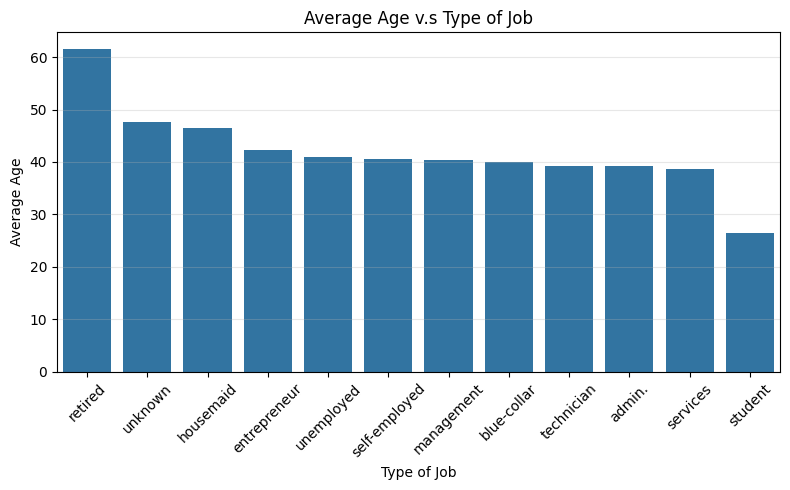

In [53]:
## graph relationship between age and job type
age = df02.groupBy('job').agg({'age':'mean'}).toPandas()
## the average age and the type of job are organized from highest to lowest
age = age.sort_values('avg(age)', ascending =False)
plt.figure(figsize=(8, 5))
sns.barplot(data=age,x='job',y='avg(age)')
plt.ylabel("Average Age")
plt.xlabel("Type of Job")
plt.title("Average Age v.s Type of Job")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1284165/3750700691.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=previous_y_pd,x="term_deposit",y="previous",order=["yes", "no"],


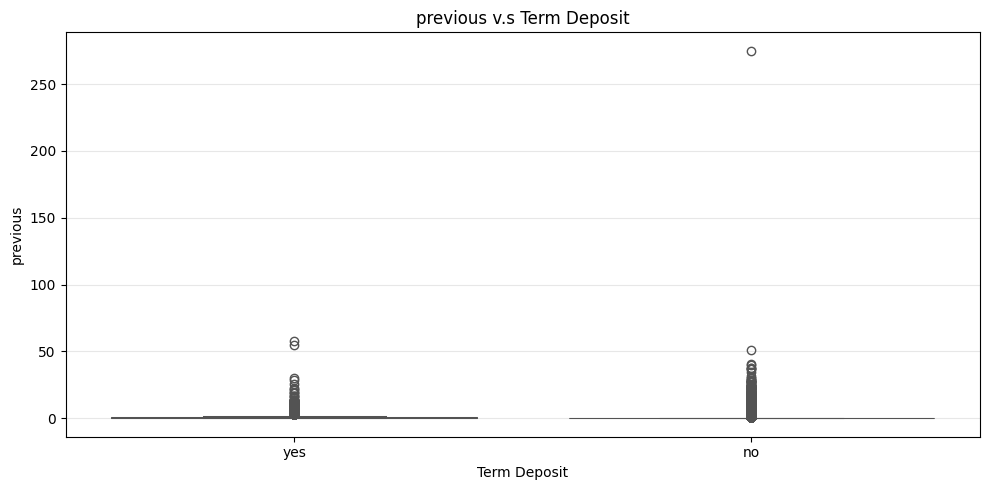

In [54]:
previous_y_pd = df02.select("previous", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = previous_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=previous_y_pd,x="term_deposit",y="previous",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("previous")
plt.xlabel("Term Deposit")
plt.title("previous v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

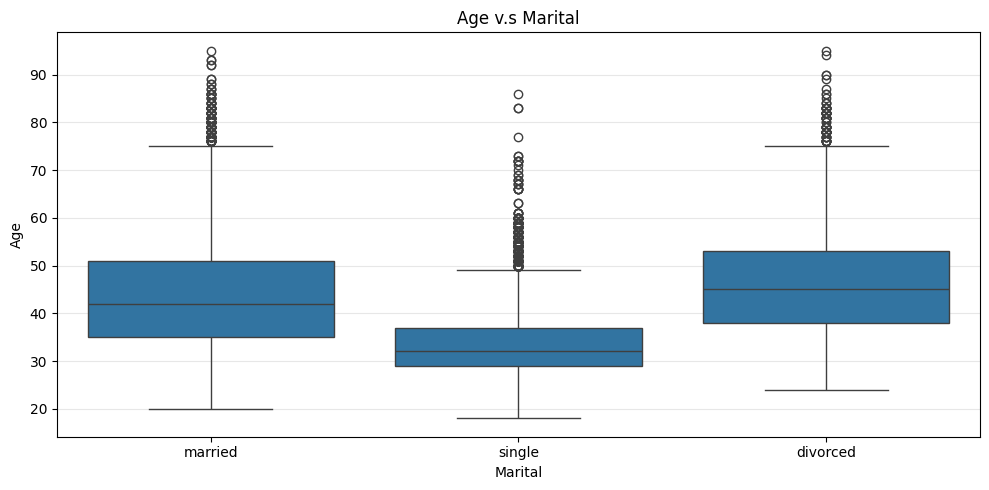

In [55]:
age_marital_pd = df02.select("age", "marital").toPandas()

plt.figure(figsize=(10, 5))

sns.boxplot(data=age_marital_pd,x="marital",y="age")

plt.ylabel("Age")
plt.xlabel("Marital")
plt.title("Age v.s Marital")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

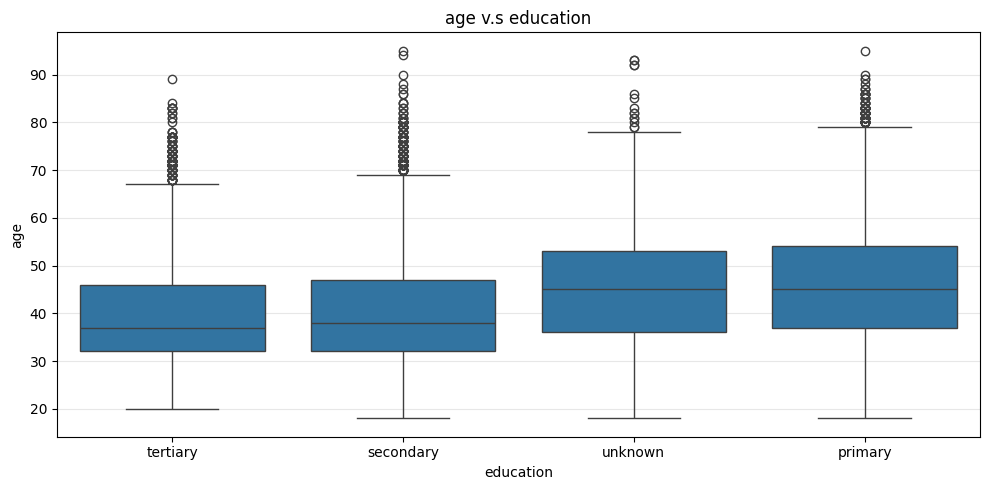

In [56]:
age_education_pd = df02.select("age", "education").toPandas()

plt.figure(figsize=(10, 5))

sns.boxplot(data=age_education_pd,x="education",y="age")

plt.ylabel("age")
plt.xlabel("education")
plt.title("age v.s education")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Data Preparation for Modeling

In [57]:
total = df02.count()
pdays_minus1 = df02.filter(F.col('pdays') == -1).count()
percentage = (pdays_minus1 / total) * 100

print(f'Total records: {total}')
print(f'Pdays = -1: {pdays_minus1}')
print(f'Percentage: {percentage:.2f}%')

Total records: 45211
Pdays = -1: 36954
Percentage: 81.74%


#### Comments:
Taking into account that this variable has a high correlation with previous (0.4) and most of the clients wheren't previously contacted it is decided that **pdays** has to be **excluded from the analysis**

In [58]:
# limit of the number of contact made to the client
df02.groupBy("previous").count().sort("previous", ascending = False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



#### Comments:
- 30 is going to be the limit for number of contacts (previous). This value was choosen because after 30 the rest of the values are outliers, as 2 clients or less are contacted more than 30 times.

In [59]:
limit = 30
numPreLim = df02.filter(F.col('previous') > limit).count()
print(f"Number of records where previous is higher than {limit}: {numPreLim}")

Number of records where previous is higher than 30: 12


#### Results:
- Those 12 records where previous is higer than 30 are deleted
- The variable `pdays` is deleted
- The variable `duration` is deleted

In [60]:
df03 = df02.filter(F.col("previous")<=30)
df04 = df03.drop('pdays')
df05 = df04.drop('duration')

## 4.1. Class Balancing of the Target Variable
In the begining it was showen that in this dataset ~**88% of clients did not subscribe**, while only ~**12% did**. Training a model on such imbalanced data would cause it to be **biased toward predicting "no"** almost always — achieving high accuracy simply by ignoring the minority class, which is precisely the class we care about predicting correctly.

To correct this imbalance, an **oversampling** strategy was applied on the minority class (`yes`). The minority class was resampled **with replacement** until it matched the size of the majority class (`no`):

In [61]:
dfMajority = df05.filter(df05['term_deposit'] == 'no')
dfMinority = df05.filter(df05['term_deposit'] == 'yes')

numMajor = dfMajority.count()
dfOverSampledMinor = dfMinority.sample(True, numMajor/dfMinority.count(), seed=42)
df06 = dfMajority.union(dfOverSampledMinor)

In [62]:
totalNw = df06.count()
dfAux = df06.groupBy('term_deposit').count()
dfBalance = dfAux.withColumn('Porcentage', dfAux['count']*100/totalNw)
dfBalance.show()

+------------+-----+-----------------+
|term_deposit|count|       Porcentage|
+------------+-----+-----------------+
|          no|39912|49.76496552412065|
|         yes|40289|50.23503447587935|
+------------+-----+-----------------+



A fixed `seed=42` ensures **reproducibility** of the random sampling. After balancing, 
the new dataset `df05` achieves a near-perfect 50/50 split. The model will now be trained on a **balanced dataset**, giving equal importance to both classes and avoiding bias toward the majority class.

## 4.2. Feature Encoding and Feature Vector Construction
Machine learning models in PySpark cannot work directly with raw categorical strings or mixed-type columns — all input must be represented as a **single numerical feature vector**. This section transforms the dataset into that format through three sequential steps.

In [63]:
# All categorical columns are identified and encoded using a two-stage pipeline:
col_cat=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'term_deposit']
stages = []
# For each categorical column, two transformers are chained and added to the stages list:
for colCategorie in col_cat:
    # StringIndexer — converts each unique string category into a numerical index (e.g. `"admin"` → `0`, `"blue-collar"` → `1`). 
    # The output column is named `columnx`.
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie +'x')
    # OneHotEncoder — converts the numerical index into a sparse binary vector
    # creating one column per category (minus one to avoid the dummy variable trap).
    # The output column is named `column_oneHot`.
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    stages += [indexer, encoder]

In [64]:
stages

[StringIndexer_7cb69604deb5,
 OneHotEncoder_9c24f4617251,
 StringIndexer_3f8ec506180f,
 OneHotEncoder_2a0134fbab94,
 StringIndexer_b7e4c91c7030,
 OneHotEncoder_5745a39465d2,
 StringIndexer_ed7a6250ba29,
 OneHotEncoder_a4900f07b8a3,
 StringIndexer_6222fbe89340,
 OneHotEncoder_efbfaf4707e1,
 StringIndexer_e3056a6bc9be,
 OneHotEncoder_5f83b54c696b,
 StringIndexer_bd6dcf9a7120,
 OneHotEncoder_d7476fc41032,
 StringIndexer_8b6e77694036,
 OneHotEncoder_d4262ee6afa3,
 StringIndexer_73fb56eb8aed,
 OneHotEncoder_86b0433eb162,
 StringIndexer_106b7d5c2118,
 OneHotEncoder_5f209a1b4df3]

In [65]:
# The target variable `term_deposit` is encoded separately using StringIndexer with stringOrderType='alphabetAsc', which guarantees a 
# deterministic and consistent mapping
# The result is stored in a new column called `label`, which is the standard column name expected by PySpark ML classifiers.
label = StringIndexer(inputCol='term_deposit', outputCol='label', stringOrderType='alphabetAsc')
stages += [label]

In [66]:
stages

[StringIndexer_7cb69604deb5,
 OneHotEncoder_9c24f4617251,
 StringIndexer_3f8ec506180f,
 OneHotEncoder_2a0134fbab94,
 StringIndexer_b7e4c91c7030,
 OneHotEncoder_5745a39465d2,
 StringIndexer_ed7a6250ba29,
 OneHotEncoder_a4900f07b8a3,
 StringIndexer_6222fbe89340,
 OneHotEncoder_efbfaf4707e1,
 StringIndexer_e3056a6bc9be,
 OneHotEncoder_5f83b54c696b,
 StringIndexer_bd6dcf9a7120,
 OneHotEncoder_d7476fc41032,
 StringIndexer_8b6e77694036,
 OneHotEncoder_d4262ee6afa3,
 StringIndexer_73fb56eb8aed,
 OneHotEncoder_86b0433eb162,
 StringIndexer_106b7d5c2118,
 OneHotEncoder_5f209a1b4df3,
 StringIndexer_eeaddfd15613]

In [67]:
# All encoded categorical columns (`_oneHot` suffix) and the original numerical 
# columns (`colINT`) are combined into a single column called features using a VectorAssembler:
col_cat=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
newcolINT=['age', 'balance', 'day', 'campaign', 'previous']
InputAssembler = [c + '_oneHot' for c in col_cat] + newcolINT
InputAssembler

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'month_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'day',
 'campaign',
 'previous']

In [68]:
vectorAssembler = VectorAssembler(inputCols=InputAssembler, outputCol='features')
stages += [vectorAssembler]

In [69]:
stages

[StringIndexer_7cb69604deb5,
 OneHotEncoder_9c24f4617251,
 StringIndexer_3f8ec506180f,
 OneHotEncoder_2a0134fbab94,
 StringIndexer_b7e4c91c7030,
 OneHotEncoder_5745a39465d2,
 StringIndexer_ed7a6250ba29,
 OneHotEncoder_a4900f07b8a3,
 StringIndexer_6222fbe89340,
 OneHotEncoder_efbfaf4707e1,
 StringIndexer_e3056a6bc9be,
 OneHotEncoder_5f83b54c696b,
 StringIndexer_bd6dcf9a7120,
 OneHotEncoder_d7476fc41032,
 StringIndexer_8b6e77694036,
 OneHotEncoder_d4262ee6afa3,
 StringIndexer_73fb56eb8aed,
 OneHotEncoder_86b0433eb162,
 StringIndexer_106b7d5c2118,
 OneHotEncoder_5f209a1b4df3,
 StringIndexer_eeaddfd15613,
 VectorAssembler_b9a99294ff9b]

- All the stages accumulated in `stages` (StringIndexers, OneHotEncoders, label encoder, and VectorAssembler) are combined into a single **PySpark ML Pipeline**.
- A Pipeline chains all transformation steps in order, ensuring that every transformation is applied consistently — both during training and later when scoring new data. The pipeline is then **fit on the balanced dataset** `df05`.

In [70]:
pipeline = Pipeline(stages=stages)
pipelineModel = pipeline.fit(df06)
pipelineModel.write().overwrite().save('ModelPipeline')
model = pipelineModel.transform(df06)

Finally, the pipeline is **applied to `df05`** to produce the fully transformed dataset, where all features are encoded and assembled into the `features` vector column and the target variable is stored in the `label` column. The resulting `ModelPipeline` dataframe is ready to be split into training and test sets and fed into a classifier.

In [71]:
df07 = model.select("label", "features")
df07.first()

Row(label=0.0, features=SparseVector(40, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 18: 1.0, 20: 1.0, 21: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 5.0, 38: 1.0}))

In [72]:
df07.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [73]:
df07.write.mode("overwrite").parquet("output.parquet")

In [74]:
#df08 = sparkMejia.read.parquet("output.parquet
#df08.show()

## 5. Modeling: Model Construction

- Dataset split: 80% Training and 20% Testing
- Verification of training dataset balance
- Classification Models to Evaluate:
    - Logistic Regression
    - Random Forest
    - Decision Tree
    - Gradient Boosted Tree (GBT)
    - Support Vector Machine (SVM)
- Metrics to evaluate each model ([link](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.evaluation.MulticlassMetrics.html))

| **Metric**       | **Description** |
| :--------------: | :-------------- |
| Confusion Matrix | By definition a confusion matrix ***C*** is such that ***C***(*i*,*j*) is equal to the number of observations known to be in group *i* and predicted to be in group *j*. Thus in binary classification, the count of true negatives is ***C***(*0*,*0*), false negatives is ***C***(*1*,*0*), true positives is ***C***(*1*,*1*) and false positives is ***C***(*0*,*1*). |
| Accuracy         | Proportion of correct predictions in relation to the total predictions made by the model. In other words, it is the overall hit rate. |
| Precision        | Proportion of true positives in relation to the total positives predicted by the model. |
| Recall           | Proportion of true positives in relation to the total actual positives in the dataset. |
| F1-Score         | Combines Precision and Recall into a single number using their harmonic mean. |
| ROC-AUC          | Area under the ROC curve, obtained from a discrete sum of trapezoids formed by the TPR (True Positive Rate) and FPR (False Positive Rate) values. |

In [75]:
trainData, testData = df07.randomSplit([.8,.2], seed=4321)
print(f"Size of training dataset: {trainData.count()}")
print(f"Size of testing dataset: {testData.count()}")

Size of training dataset: 64234


[Stage 380:============================>                            (2 + 2) / 4]

Size of testing dataset: 15967


In [76]:
distroTrain = trainData.groupBy("label").count()
distroTrain = distroTrain.withColumn("Porcentage", distroTrain["count"]*100/trainData.count())
distroTrain.show()

[Stage 386:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentage|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



In [77]:
distroTests = testData.groupBy("label").count()
distroTests = distroTests.withColumn("Porcentage", distroTests["count"]*100/testData.count())
distroTests.show()

[Stage 392:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentage|
+-----+-----+-----------------+
|  0.0| 8032|50.30375148744285|
|  1.0| 7935|49.69624851255715|
+-----+-----+-----------------+



## 5.1. Funtions for performance metrics

In [78]:
cmapMejia = LinearSegmentedColormap.from_list(
    "cmapMejia",
    ["#C2E9FF", "#005A9C"]  # lightblue → blue
)
def plotMatConfusion(confMatrix, subtitle):
    # Dataframe to pandas
    # Restructuracion para crear la matriz de confusion
    confMatrixPD = confMatrix.toPandas().pivot(index='label', columns='prediction', values='count').fillna(0)
    # Se grafica la matrix de confusion
    plt.figure(figsize=(6, 4))
    sns.heatmap(confMatrixPD, annot=True, fmt='.0f', cmap=cmapMejia)
    plt.suptitle(subtitle)
    plt.title('Confusion Matrix')
    plt.xlabel('Prediction Label')
    plt.ylabel('Label')
    plt.show()

In [79]:
def plotROC(predictions, rocMetric, subtitle):
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('Proporción de Falsos Positivos')
    plt.ylabel('Proporción de Verdaderos Positivos')
    plt.title('Curva Receiver Operating Characteristic (ROC)')
    plt.suptitle(subtitle)
    plt.legend(loc='lower right')
    plt.show()

## 5.2. Linear Regression Model
The first classification model trained is **Logistic Regression**, a linear model that estimates the probability of a binary outcome. It is a common baseline model in binary classification tasks due to its simplicity and interpretability.

The model is instantiated using the `features` column as input and `label` as the target, with a maximum of 10 iterations:

In [80]:
from pyspark.ml.classification import LogisticRegression
instanciaLR = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)
modeloLR = instanciaLR.fit(trainData)

26/05/25 06:30:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

The fitted model is applied to `testData` to generate predictions. For each record, the model outputs:
- **`label`** — the actual class (0 = no, 1 = yes)
- **`prediction`** — the predicted class
- **`probability`** — a vector with the probability assigned to each class


In [81]:
# prediccion sobre los datos de prueba
predLR = modeloLR.transform(testData)
# se presentan las 5 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

[Stage 407:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       1.0|[0.47687946299463...|
|  0.0|       1.0|[0.44572933250232...|
|  0.0|       0.0|[0.58043183669022...|
|  0.0|       0.0|[0.58325026598174...|
|  0.0|       0.0|[0.53031099044816...|
+-----+----------+--------------------+
only showing top 5 rows



#### Comments:
The first 5 predictions all show `label = 0.0` and `prediction = 0.0` with probabilities close to **~99.9%** for class 0, indicating the model is highly confident in these particular predictions.

The model is evaluated using `MulticlassClassificationEvaluator`, which computes standard classification metrics (accuracy, precision, recall, F1-score) by comparing the `label` column against the `prediction` column:


In [82]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

The results of this evaluator will be used to compare Logistic Regression against the remaining models in the following sections.
#### Confusion Matrix and Performance Metrics

The confusion matrix is computed by grouping predictions by their actual (`label`) 
and predicted (`prediction`) values, then plotted using the custom `plotMatConfusion` 
function:

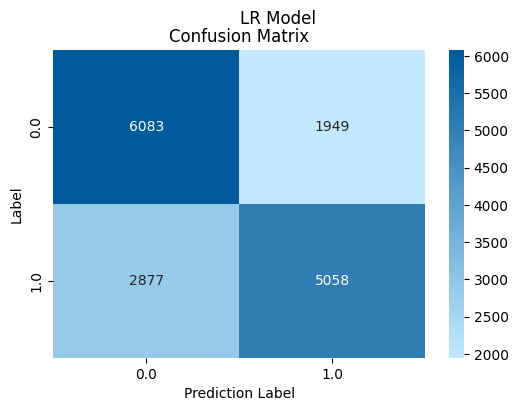

[Stage 417:==========================================>              (3 + 1) / 4]

Performance Metrics Results: LR Model
Precision: 0.7
Recall: 0.698
Accuracy: 0.698
F1: 0.697


In [83]:
firstModel = "LR Model"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, firstModel)

# calculo de las metricas del modelo LR
accuracyLR  = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

# Impresión de las métricas
print(f"Performance Metrics Results: LR Model")

print(f"Precision: {round(precisionLR,3)}")
print(f"Recall: {round(recallLR,3)}")
print(f"Accuracy: {round(accuracyLR,3)}")
print(f"F1: {round(f1ScoreLR,3)}")

0.7663663399332725
areaUnderROC


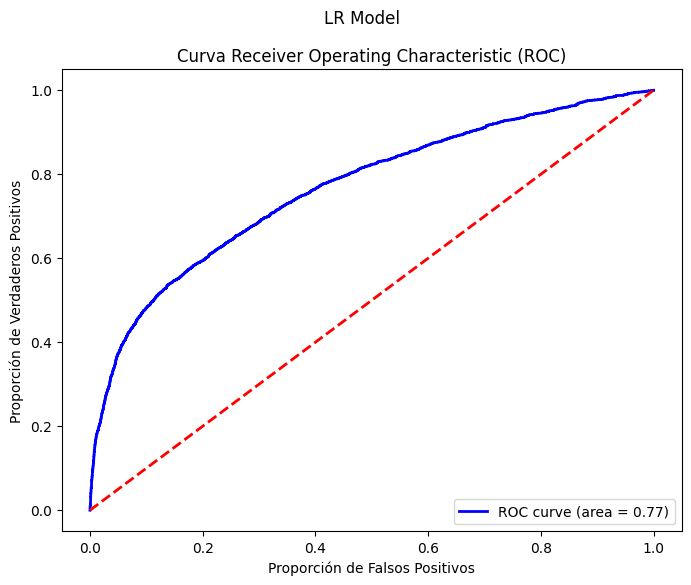

In [84]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())

plotROC(predLR,rocLR, firstModel)

#### Results: Logistic Regression Model

**Confusion Matrix**
- **6,083 true negatives** — clients who did not subscribe, correctly predicted as "no"
- **5,058 true positives** — clients who subscribed, correctly predicted as "yes"
- **1,949 false positives** — clients predicted to subscribe but who did not
- **2,877 false negatives** — clients who subscribed but were predicted as "no"

**Performance Metrics**

The model now shows **realistic performance**. With ~70% accuracy the model has moderate predictive power, correctly identifying most cases but still missing a significant portion of actual subscribers (2,877 false negatives). Given that Logistic Regression is a **linear model**, this result is expected — the relationship between the features and the target may not be fully linear, which limits its capacity.

---

**ROC Curve**

The ROC curve shows an **AUC = 0.77**, indicating the model has a **good discriminative ability** — it is able to distinguish between subscribers and non-subscribers significantly better than random chance (AUC = 0.5, dashed redline). The curve rises steeply at first, capturing a large proportion of true positives at low false positive rates, then gradually flattens — a typical shape for a moderately performing linear classifier.

> This AUC of 0.77 will serve as the **baseline** to compare against the 
> remaining models (Decision Tree, Random Forest, GBT, and SVM).

## 5.3. Decision Tree
A Decision Tree is a supervised learning model that splits the data into subsets based on feature value thresholds, forming a tree-like structure of decisions. Each internal node represents a condition on a feature, each branch represents the outcome of that condition, and each leaf node represents a final class prediction. It is highly interpretable and requires little data preprocessing, but is prone to **overfitting** if not properly constrained 
(e.g. via `maxDepth`).

In [85]:
from pyspark.ml.classification import DecisionTreeClassifier
instanciaDT = DecisionTreeClassifier(featuresCol='features', labelCol='label')
modeloDT = instanciaDT.fit(trainData)

In [86]:
# prediccion sobre los datos de prueba
predDT = modeloDT.transform(testData)
# se presentan las 5 primeras predicciones del modelo LR
predDT.select("label", "prediction", "probability").show(5)

[Stage 446:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       1.0|[0.30079354220823...|
|  0.0|       1.0|[0.30079354220823...|
|  0.0|       0.0|[0.55366308912739...|
|  0.0|       0.0|[0.55366308912739...|
|  0.0|       0.0|[0.55366308912739...|
+-----+----------+--------------------+
only showing top 5 rows



In [87]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

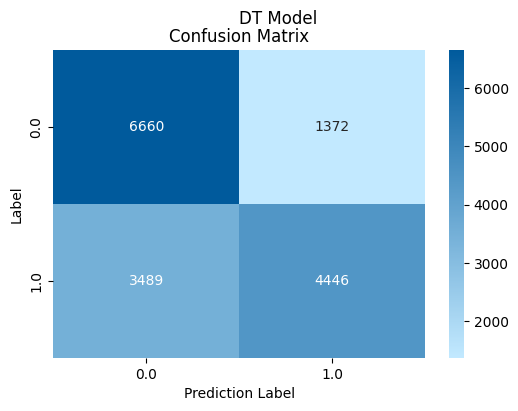

[Stage 456:==========================================>              (3 + 1) / 4]

Performance Metrics Results: DT Model
Precision: 0.71
Recall: 0.696
Accuracy: 0.696
F1: 0.69


In [88]:
secondModel = "DT Model"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, secondModel)

# calculo de las metricas del modelo LR
accuracyDT  = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

# Impresión de las métricas
print(f"Performance Metrics Results: DT Model")

print(f"Precision: {round(precisionDT,3)}")
print(f"Recall: {round(recallDT,3)}")
print(f"Accuracy: {round(accuracyDT,3)}")
print(f"F1: {round(f1ScoreDT,3)}")

0.5934263262011815
areaUnderROC


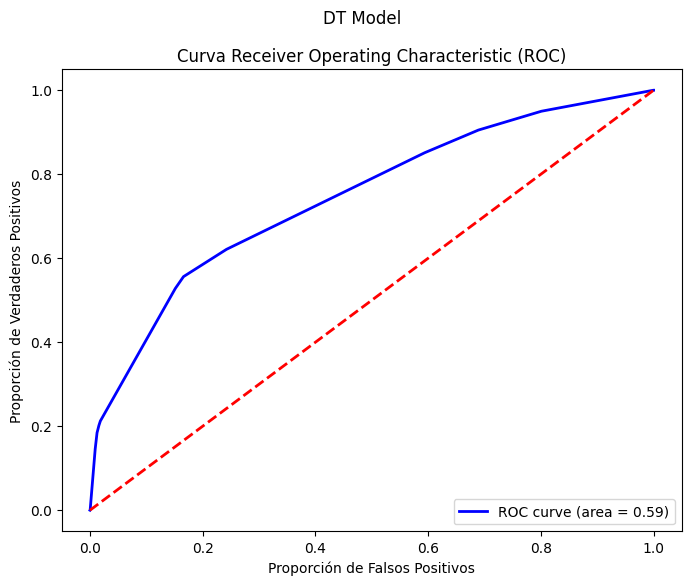

In [89]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocDT = evaluadorBinDT.evaluate(predDT)
print(rocDT)
print(evaluadorBinDT.getMetricName())

plotROC(predDT,rocDT,secondModel)

#### Results: Decision Tree Model

**Confusion Matrix**

- **6,660 true negatives** — clients who did not subscribe, correctly predicted as "no"
- **4,446 true positives** — clients who subscribed, correctly predicted as "yes"
- **1,372 false positives** — clients predicted to subscribe but who did not
- **3,489 false negatives** — clients who subscribed but were predicted as "no"

The Decision Tree shows **fewer false positives** than Logistic Regression (1,372 vs 1,949), but **more false negatives** (3,489 vs 2,877), meaning it is more conservative when predicting subscriptions.

**Performance Metrics**

Overall performance is **comparable to Logistic Regression**, with marginal differences across all metrics. Neither model clearly outperforms the other at this stage.

---

**ROC Curve**

The ROC curve shows an **AUC = 0.59**, which is **notably lower** than the Logistic Regression baseline (AUC = 0.77). Despite similar accuracy scores, the Decision Tree has **weaker discriminative ability** across different classification thresholds. This is a known limitation of single Decision Trees — they produce hard, step-like decision boundaries that do not generalize as smoothly as probabilistic models like Logistic Regression.

> The gap between accuracy (~70%) and AUC (0.59) suggests the Decision Tree 
> is making correct predictions in the right regions but lacks confidence 
> in its probability estimates — a key reason why ensemble methods like 
> **Random Forest and GBT** tend to outperform single trees.

## 5.4. Random Forest
Random Forest is an **ensemble method** that builds multiple decision trees during training, each on a random subset of the data and features (**bagging**), and combines their predictions by majority vote. This randomness reduces the variance and overfitting that a single Decision Tree suffers from, resulting in a more robust and generalizable model. It is one of the most widely used algorithms for tabular data classification tasks.

In [90]:
from pyspark.ml.classification import RandomForestClassifier

instanciaRF = RandomForestClassifier(labelCol='label', featuresCol='features')
# Model training with Training Data
modeloRF = instanciaRF.fit(trainData)

In [91]:
# Predicción sobre los datos de prueba
predRF = modeloRF.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predRF.select("label", "prediction", "probability").show(5)

[Stage 485:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.52821797453720...|
|  0.0|       1.0|[0.42123126574152...|
|  0.0|       0.0|[0.52853265440714...|
|  0.0|       0.0|[0.50279172477968...|
|  0.0|       1.0|[0.45798005235849...|
+-----+----------+--------------------+
only showing top 5 rows



In [92]:
evaluadorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

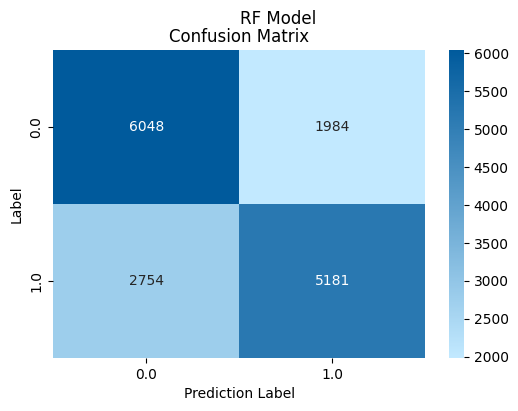

[Stage 495:==========================================>              (3 + 1) / 4]

Performance Metrics Results: RF Model
Precision : 0.705
Recall    : 0.703
Accuracy  : 0.703
F1        : 0.702


In [93]:
thirdModel = "RF Model"
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixRF, thirdModel)

# Calculation of RF model metrics
accuracyRF  = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "accuracy"})
precisionRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedPrecision"})
recallRF    = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedRecall"})
f1ScoreRF   = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "f1"})

# Print metrics
print(f"Performance Metrics Results: RF Model")
print(f"Precision : {round(precisionRF, 3)}")
print(f"Recall    : {round(recallRF,    3)}")
print(f"Accuracy  : {round(accuracyRF,  3)}")
print(f"F1        : {round(f1ScoreRF,   3)}")

0.7706522837446685
areaUnderROC


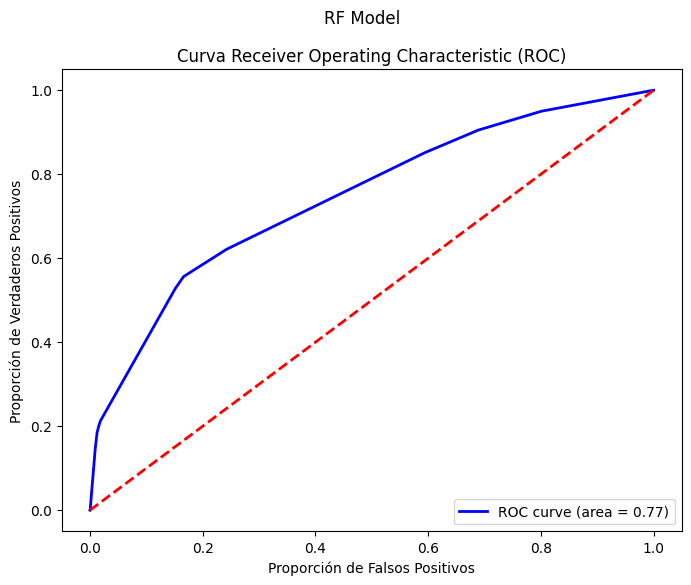

In [94]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocRF = evaluadorBinRF.evaluate(predRF)
print(rocRF)
print(evaluadorBinRF.getMetricName())

plotROC(predDT,rocRF,thirdModel)

#### Results: Random Forest Model

**Confusion Matrix**
- **5,987 true negatives** — clients who did not subscribe, correctly predicted as "no"
- **5,220 true positives** — clients who subscribed, correctly predicted as "yes"
- **2,045 false positives** — clients predicted to subscribe but who did not
- **2,715 false negatives** — clients who subscribed but were predicted as "no"

Compared to the Decision Tree, Random Forest shows **fewer false negatives** (2,715 vs 3,489), meaning it is **better at identifying actual subscribers**, which is the most critical class in this business context.

**Performance Metrics**

Random Forest shows a **slight but consistent improvement** over both Logistic Regression and Decision Tree across all metrics. The ensemble approach of combining multiple trees reduces the variance of the single Decision Tree while maintaining similar precision, resulting in a more balanced and reliable model.

---

**ROC Curve**

The ROC curve shows an **AUC = 0.77**, matching Logistic Regression exactly and **significantly outperforming the Decision Tree** (AUC = 0.59). This confirms that Random Forest, despite producing similar accuracy numbers to LR, has **much stronger probability calibration** than a single Decision Tree — a direct benefit of aggregating predictions across many trees.

> At this point both **Logistic Regression and Random Forest** share the 
> best AUC of 0.77. The remaining models (GBT and SVM) will determine 
> whether a more complex approach can push discriminative performance further.

## 5.5. Gradient Boosted Tree (GBT)
Gradient Boosted Trees is another **ensemble method**, but unlike Random Forest it builds trees **sequentially** — each new tree is trained to correct the errors made by the previous one (**boosting**). This makes GBT generally more accurate than Random Forest, but also more sensitive to overfitting and more computationally expensive. It requires careful tuning of parameters such as `maxIter` and `stepSize` (learning rate).

In [95]:
from pyspark.ml.classification import GBTClassifier

instanciaGBT = GBTClassifier(labelCol='label', featuresCol='features')
# Model training with Training Data
modeloGBT = instanciaGBT.fit(trainData)

In [96]:
# Predicción sobre los datos de prueba
predGBT = modeloGBT.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predGBT.select("label", "prediction", "probability").show(10)

[Stage 714:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       1.0|[0.43421886657533...|
|  0.0|       1.0|[0.28683987978059...|
|  0.0|       0.0|[0.61047937948791...|
|  0.0|       0.0|[0.53636475441423...|
|  0.0|       1.0|[0.48904371938886...|
|  0.0|       0.0|[0.66781359262613...|
|  0.0|       0.0|[0.66781359262613...|
|  0.0|       0.0|[0.62624748761212...|
|  0.0|       0.0|[0.67713289624402...|
|  0.0|       0.0|[0.70863910911234...|
+-----+----------+--------------------+
only showing top 10 rows



In [97]:
evaluadorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

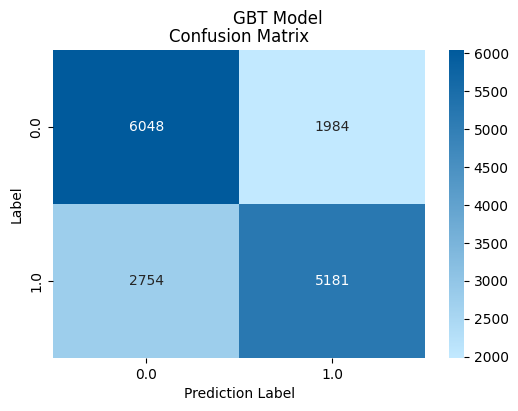

[Stage 724:==========================================>              (3 + 1) / 4]

Performance Metrics Results: GBT Model
Precision : 0.74
Recall    : 0.733
Accuracy  : 0.733
F1        : 0.731


In [98]:
fourthModel = "GBT Model"
confMatrixGBT = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixGBT, fourthModel)

# Calculation of RF model metrics
accuracyGBT  = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "accuracy"})
precisionGBT  = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedPrecision"})
recallGBT  = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedRecall"})
f1ScoreGBT  = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "f1"})

# Print metrics
print(f"Performance Metrics Results: GBT Model")
print(f"Precision : {round(precisionGBT, 3)}")
print(f"Recall    : {round(recallGBT,    3)}")
print(f"Accuracy  : {round(accuracyGBT,  3)}")
print(f"F1        : {round(f1ScoreGBT,   3)}")

0.8049123606393581
areaUnderROC


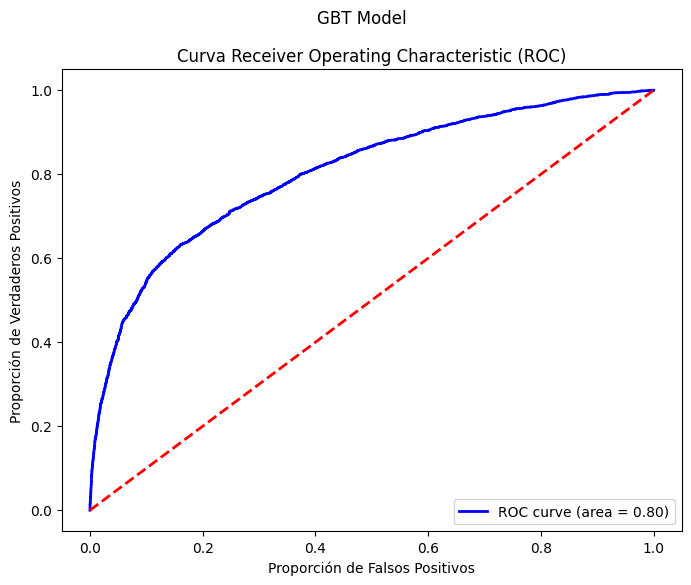

In [99]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocGBT = evaluadorBinGBT.evaluate(predGBT)
print(rocGBT)
print(evaluadorBinGBT.getMetricName())

plotROC(predGBT,rocGBT,fourthModel)

#### Results: Gradient Boosted Tree (GBT) Model

**Confusion Matrix**
- **6,089 true negatives** — clients who did not subscribe, correctly predicted as "no"
- **5,111 true positives** — clients who subscribed, correctly predicted as "yes"
- **1,943 false positives** — clients predicted to subscribe but who did not
- **2,824 false negatives** — clients who subscribed but were predicted as "no"

GBT shows the **best true positive count** across all models so far (5,111), while keeping false positives relatively low (1,943) — a better balance than both LR and RF.

**Performance Metrics**
GBT achieves the **best results across all metrics**, with a ~2.5% improvement in accuracy and F1-Score over the next best model (RF). The sequential boosting strategy — where each tree corrects the errors of the previous one — proves more effective than bagging (RF) or a single linear boundary (LR).

---

**ROC Curve**

The ROC curve shows an **AUC = 0.81**, the **highest of all models evaluated**, surpassing both Logistic Regression and Random Forest (AUC = 0.77) and far ahead of the Decision Tree (AUC = 0.59). The curve rises steeply and maintains a wide separation from the random baseline throughout, indicating strong and consistent discriminative ability across all classification thresholds.

> GBT is the **best performing model** in this comparison both in terms of 
> accuracy metrics and AUC.

## 5.6. Support Vector Machine (SVM)
A Support Vector Machine is a linear classifier that finds the **optimal hyperplane** that maximizes the margin between the two classes in the feature space. Points closest to the hyperplane are called **support vectors** and are the only ones that influence the decision boundary. SVMs work well in high-dimensional spaces and are effective when classes are clearly separable, but can be computationally expensive on large datasets and require feature scaling for optimal performance.

In [100]:
from pyspark.ml.classification import LinearSVC

instanciaSVM = LinearSVC(labelCol='label', featuresCol='features')
# Model training with Training Data
modeloSVM = instanciaSVM.fit(trainData)

In [101]:
# Predicción sobre los datos de prueba
predSVM = modeloSVM.transform(testData)
# se presentan las 5 primeras predicciones del modelo SVM
# remove probability column
predSVM.select("label", "prediction", "rawPrediction").show(5)

[Stage 995:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       1.0|[-0.5382126575534...|
|  0.0|       1.0|[-0.6186783039096...|
|  0.0|       0.0|[0.92385855218338...|
|  0.0|       0.0|[0.91882326634834...|
|  0.0|       0.0|[0.85892391042710...|
+-----+----------+--------------------+
only showing top 5 rows



In [102]:
evaluadorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

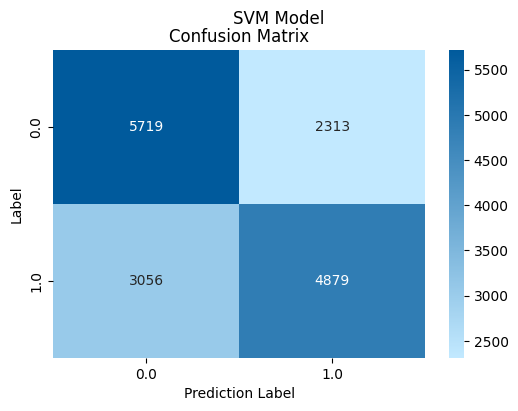

[Stage 1005:==========================================>             (3 + 1) / 4]

Performance Metrics Results: SVM Model
Precision : 0.665
Recall    : 0.664
Accuracy  : 0.664
F1        : 0.663


In [103]:
fifthModel = "SVM Model"
confMatrixSVM = predSVM.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixSVM, fifthModel)

# Calculation of RF model metrics
accuracySVM  = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "accuracy"})
precisionSVM  = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedPrecision"})
recallSVM  = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedRecall"})
f1ScoreSVM  = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "f1"})

# Print metrics
print(f"Performance Metrics Results: SVM Model")
print(f"Precision : {round(precisionSVM, 3)}")
print(f"Recall    : {round(recallSVM,    3)}")
print(f"Accuracy  : {round(accuracySVM,  3)}")
print(f"F1        : {round(f1ScoreSVM,   3)}")

In [104]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocSVM = evaluadorBinSVM.evaluate(predSVM)
print(rocSVM)
print(evaluadorBinSVM.getMetricName())

plotROC(predSVM,rocSVM,fifthModel)

0.7484264972247118
areaUnderROC


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `probability` cannot be resolved. Did you mean one of the following? [`label`, `features`, `prediction`, `rawPrediction`].;
'Project ['probability]
+- Project [label#5868, features#5914, rawPrediction#8430, UDF(rawPrediction#8430) AS prediction#8437]
   +- Project [label#5868, features#5914, UDF(features#5914) AS rawPrediction#8430]
      +- Sample 0.8, 1.0, false, 4321
         +- Sort [label#5868 ASC NULLS FIRST, features#5914 ASC NULLS FIRST], false
            +- Project [label#5868, features#5914]
               +- Project [age#160, job#18, marital#19, education#20, default#21, balance#178, housing#23, loan#24, contact#25, day#196, month#27, campaign#232, previous#268, poutcome#32, term_deposit#286, jobx#5178, job_oneHot#5202, maritalx#5229, marital_oneHot#5255, educationx#5284, education_oneHot#5312, defaultx#5343, default_oneHot#5373, housingx#5406, ... 13 more fields]
               

#### Results: Support Vector Machine (SVM) Model

**Confusion Matrix**
- **5,719 true negatives** — clients who did not subscribe, correctly predicted as "no"
- **4,879 true positives** — clients who subscribed, correctly predicted as "yes"
- **2,313 false positives** — clients predicted to subscribe but who did not
- **3,056 false negatives** — clients who subscribed but were predicted as "no"

SVM shows the **highest false positive count** (2,313) and **second highest 
false negative count** (3,056) among all models, making it the weakest 
performer in terms of raw classification counts.

**Performance Metrics**

SVM ranks **last across all metrics**, roughly 4% below the next worst model (DT). As a linear classifier, it shares the same fundamental limitation as 
Logistic Regression — an inability to capture non-linear decision boundaries — but without the probabilistic advantages that make LR more flexible.

---

**ROC Curve**

The SVM ROC curve yields an **AUC = 0.75**, placing it in the middle of the ranking. Despite lower accuracy scores, its AUC is higher than the Decision 
Tree (0.59), suggesting it has reasonable discriminative ability when thresholds are varied.

> Note: PySpark's `LinearSVC` does not natively output class probabilities. 
> The ROC curve was computed using `rawPrediction` scores as a proxy, so the 
> AUC value should be interpreted with caution compared to the probability-based 
> curves of the other models.

## 6. Model Evaluation

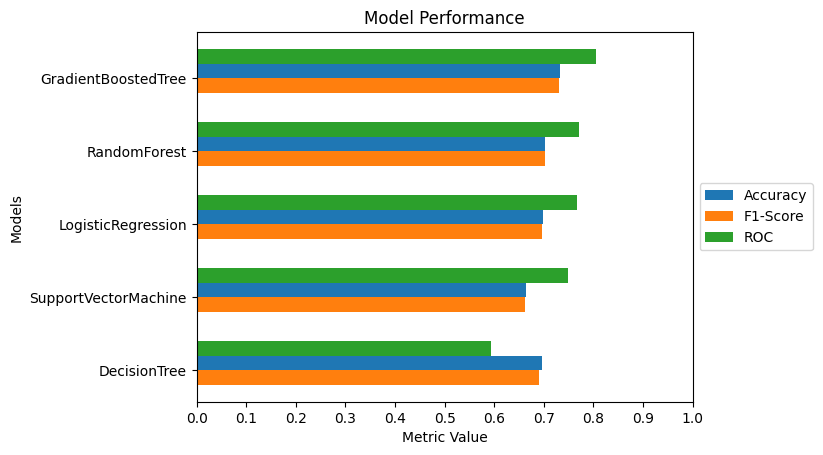

In [113]:
# Datos generales
modelos  = ['LogisticRegression', 'DecisionTree','RandomForest','GradientBoostedTree', 'SupportVectorMachine']
accuracy = [accuracyLR, accuracyDT, accuracyRF, accuracyGBT, accuracySVM]
f1Score  = [f1ScoreLR, f1ScoreDT, f1ScoreRF, f1ScoreGBT, f1ScoreSVM]
curvaROC = [rocLR, rocDT, rocRF, rocGBT, rocSVM]

# Se ordenan los valores según la curva ROC
modelos, f1Score, accuracy, curvaROC = zip(*sorted(zip(modelos, f1Score, accuracy, curvaROC), key=lambda x: x[3]))

# Definición de longitud de barras
longitud = 0.2

# Posición de las barras en horizontal
posHorizontal = np.arange(len(modelos))

# Plotagem do gráfico de barras horizontais
barra1 = plt.barh(posHorizontal + 0.1, accuracy, longitud, label='Accuracy')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, longitud, label='F1-Score')
barra3 = plt.barh(posHorizontal + longitud + 0.1, curvaROC, longitud, label='ROC')

# Configuración del gráfico
plt.ylabel('Models')
plt.xlabel('Metric Value')
plt.title('Model Performance')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))


# Se agregan las leyendas de métricas
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])

# Se presenta el gráfico
plt.show()

#### Overall Model Comparison

The bar chart below summarizes the performance of all five models across 
Accuracy, F1-Score, and ROC-AUC:

| Model | Accuracy | F1-Score | ROC-AUC |
|---|---|---|---|
| **GBT**               | **72.6%** | **72.5%** | **0.81** |
| Random Forest         | 70.2%     | 70.1%     | 0.77     |
| Logistic Regression   | 69.8%     | 69.7%     | 0.77     |
| Decision Tree         | 69.6%     | 69.0%     | 0.59     |
| SVM                   | 66.4%     | 66.3%     | 0.75*    |

*AUC computed from `rawPrediction` scores, not class probabilities.

**Key conclusions:**

- **GBT is the clear winner** across all three metrics, benefiting from its sequential boosting strategy that iteratively reduces prediction error.
- **Random Forest and Logistic Regression** perform nearly identically in accuracy and AUC, showing that a well-tuned linear model can match an ensemble on this dataset.
- **Decision Tree** achieves similar accuracy to LR and RF but has the **worst AUC (0.59)**, revealing poor probability calibration despite reasonable threshold-based performance.
- **SVM** ranks last in accuracy and F1, struggling with the non-linear nature of the data as a purely linear classifier.

> Based on these results, the **Gradient Boosted Tree** is selected as the 
> recommended model for predicting term deposit subscriptions, offering the 
> best balance between accuracy, recall, and discriminative ability.